# Projeto Final - Processamento de Linguagem Natural
**Nomes:** Laura Medeiros Dal Ponte e Mariana Melo Pereira

## Introdução
Os "dog whistles" (apitos de cachorro) são uma forma de comunicação codificada cujo uso vêm se popularizando no meio digital, como em redes sociais e fóruns online. O nome é uma analogia ao fato que apitos de cachorro produzem uma sonoridade que somente cães conseguem ouvir. Da mesma forma, dog whistles configuram termos específicos que, de forma generalizada, possuem um significado normal para o público geral, porém para um grupo alvo específico, como grupos ideológicos extremos, ganham uma conotação frequentemente associada a perpetuação de ódio contra minorias.

Recentemente, com a amplificação de modelos de linguagem natural (LLM), é possível treinar modelos que identifiquem termos ofensivos e potencialmente problemáticos, facilitando o monitoramento de postagens em ambientes virtuais. Todavia, termos codificados trazem problemáticas quanto a sua característica altamente contextual. Diferente de termos já bem identificados como provenientes de discurso de ódio, dog whistles podem ser facilmente confundidos com palavras de uso comum. Existe um repositório limitado de modelos LLM que consigam fazer essa diferenciação, em razão não apenas da alta dependência do contexto, mas também a grande diversidade de códigos existentes [ref]. O objetivo desse trabalho é explorar se um modelo de LLM consegue identificar dog whistles previamente anotados e, posterior a isso, descobrir se esse modelo poderia diferenciar um dog whistle de uma palavra comum baseado no seu contexto.

### Pergunta da pesquisa
Dado o contexto levantado na Introdução do presente notebook, queremos responder à seguinte pergunta:
> Como técnicas de Processamento de Linguagem Natural podem identificar, caracterizar e distinguir o uso contextual de dog whistles em textos formais e informais?

### Hipótese 1 - Detecção Lexical
> Representações lexicais, como Bag-of-Words e TF-IDF, são capazes de identificar a presença de termos associados a dog whistles.

### Hipótese 2 - Interpretação contextual
> A distinção entre o uso convencional e o uso como dog whistle exige informações contextuais e, portanto, representações semânticas, como embeddings, similaridade textual e/ou análise por LLM, podem fornecer informações adicionais às representações puramente lexicais.

In [1]:
!pip install gensim

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Importação das bibliotecas

In [1]:
import re
import numpy as np
import pandas as pd
import spacy
from nltk.util import ngrams

from datasets import load_dataset
from collections import Counter

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize

from gensim.models import Word2Vec
from transformers import AutoTokenizer, AutoModel

import json
import os

from openai import OpenAI

import getpass
import json
import time

[transformers] Disabling PyTorch because PyTorch >= 2.5 is required but found 2.4.1+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


### Configurações iniciais

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Construção do dataset

- Classe positiva: `AstroAure/dogwhistle_dataset` (exemplos contendo dog whistles)
- Classe negativa: `HuggingFaceGECLM/REDDIT_comments` (comentários sem dog whistle)

O objetivo também é construir um conjunto balanceado.

#### Processando o dataset `AstroAure/dogwhistle_dataset`

O dataset `AstroAure/dogwhistle_dataset` une três variações do Silent Signals:
- SALT-NLP/silent_signals: Dogwhistles identificados
- SALT-NLP/informal_potential_dogwhistles: Dogwhistles potenciais no Reddit
- SALT-NLP/formal_potential_dogwhistles: Dogwhistles potenciais no Congresso americano

In [3]:
ds_astro = load_dataset("AstroAure/dogwhistle_dataset", streaming=True)

astro_rows = []

for i, row in enumerate(ds_astro["train_b"]):
    astro_rows.append(row)

df_astro_inicial = pd.DataFrame(astro_rows)

print(df_astro_inicial.shape)

(28900, 5)


Abaixo, podemos observar que ele possui 5 atributos: 
- `label`: 1 = contém palavra com sentido de dog whistle, 0 = contém dog whistle (sem o sentido de dog whistle)
- `content`: o corpo do texto da postagem
- `dog_whistle`: o termo presente que poderia ser considerado como um dog whistle
- `ingroup`: a qual grupo de classificação o dog whistle potencial pertence
- `type`: contexto formal ou informal

In [4]:
print(df_astro_inicial['dog_whistle'].unique())

['institution of marriage' 'cuckolds' 'SJW' 'special interest' 'cabal'
 'working families' 'male socialization' 'centipede' 'based' 'Google'
 'single mom' 'terrorism' 'beta' 'single' 'cuck' 'affirmative action'
 'middle class' 'diversity quotas' 'inner cities'
 'social justice warriors' 'terrorist' 'single parent' 'trans activist'
 'dindus' 'Kek' 'MAGA' 'pedes' 'biological woman' 'bix nood' 'beta male'
 'Pajeets' 'Chicago' 'multiCULTi' 'safeguard' 'oy vey' 'Baltimore' 'pede'
 'coincidence' 'absent father' 'illegal immigrant' 'the Fed'
 'entitlement program' 'single mother' 'racial realism' 'Pepe'
 'hardworking Americans' 'race realism' 'Islamists' 'terrorists'
 'genderist' "Let's Go Brandon" 'welfare' 'tax cut' 'alt-right'
 'school vouchers' 'job creation' 'New York intellectuals' 'TRA'
 'snowflake' 'securing our border' 'dual loyalty' 'Hollywood' 'baby mama'
 'religious liberty' 'neolibs' 'agender' 'fraudulent voting' 'CRT'
 'public schools' 'biological sex is real' 'gender crit' 'ent

In [5]:
df_astro_inicial

,label,content,dog_whistle,ingroup,type
0,1,Although I believe we must be extremely carefu...,institution of marriage,homophobic,Formal
1,1,Good. Swedish cuckolds are an infestation on s...,cuckolds,white supremacist,Informal
2,0,"Ah, gotcha, you're not an SJW, just didn't lik...",SJW,anti-liberal,Informal
3,0,It is currently fashionable to say that all of...,special interest,antisemitic,Formal
4,0,You may be aware that corporate logos hint at ...,cabal,antisemitic,Informal
...,...,...,...,...,...
28895,0,Like is your system more based around freedom ...,based,white supremacist,Informal
28896,0,Apple maps took me to a flyover and as I got h...,Google,racist,Informal
28897,0,Sometimes it feels we're back in 1600s Scotlan...,freedom of religion,homophobic,Informal
28898,1,True. Firefox is less of an enemy and globalis...,octopus,antisemitic,Informal


Todos os exemplos que possuem, então, termos em que existe a probabilidade de serem classificados como dog whistles. Para abordar o problema da etapa 1, porém, precisamos de exemplos em que esses termos não existam nos textos considerados (ausência de dog whistles). Nesse caso, utilizamos o dataset `HuggingFaceGECLM/REDDIT_comments`.

#### Processando o dataset `HuggingFaceGECLM/REDDIT_comments`

In [6]:
ds_pushshift = load_dataset("HuggingFaceGECLM/REDDIT_comments", streaming=True)

pushshift_rows = []

for i, row in enumerate(ds_pushshift["IWantToLearn"]):
    
    pushshift_rows.append(row)
    
    if i + 1 >= 14450:
        break

df_pushshift_inicial = pd.DataFrame(pushshift_rows)

print(df_pushshift_inicial.shape)

Resolving data files:   0%|          | 0/21 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/20 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/45 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/22 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/46 [00:00<?, ?it/s]

(14450, 21)


Ele possui muitos atributos; porém, para o nosso problema, o que importa é realmente o "body"; ou seja, o texto publicado propriamente dito.

In [7]:
df_pushshift_inicial

,archived,author,author_fullname,body,comment_type,controversiality,created_utc,edited,gilded,id,...,locked,name,parent_id,permalink,retrieved_on,score,subreddit_id,subreddit_name_prefixed,subreddit_type,total_awards_received
0,True,xtirpation,None,"Well, I'm no cook, but can't you just quickly ...",None,0,1267341945,False,0,c0lbxm0,...,None,t1_c0lbxm0,t3_b7ev9,None,1426227697,1,t5_2rjo5,None,None,None
1,True,E_lucas,None,Learn to juggle.\n\nThink about lolcats.\n\nIf...,None,0,1267342012,False,0,c0lbxnw,...,None,t1_c0lbxnw,t3_b7euu,None,1426227698,1,t5_2rjo5,None,None,None
2,True,elayyou,None,tastespotting.com,None,0,1267342383,False,0,c0lbxxd,...,None,t1_c0lbxxd,t3_b7ev9,None,1426227702,1,t5_2rjo5,None,None,None
3,True,xtirpation,None,"sounds good, i'll start on the first one right...",None,0,1267342559,False,0,c0lby1o,...,None,t1_c0lby1o,t1_c0lbxnw,None,1426227703,2,t5_2rjo5,None,None,None
4,True,E_lucas,None,"You can't just post recipes, it doesn't help w...",None,0,1267342599,False,0,c0lby2o,...,None,t1_c0lby2o,t1_c0lbxxd,None,1426227703,1,t5_2rjo5,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14445,True,buu700,None,"Awesome, thanks.\n\nI have TuxGuitar running; ...",None,0,1293958508,False,0,c1b4ups,...,None,t1_c1b4ups,t1_c19uwm6,None,1426666650,1,t5_2rjo5,None,None,None
14446,True,buu700,None,"This looks really cool, thanks! Taking a look ...",None,0,1293958535,False,0,c1b4ur0,...,None,t1_c1b4ur0,t1_c19ufev,None,1426666650,1,t5_2rjo5,None,None,None
14447,True,buu700,None,Thanks a lot for the advice. We're actually go...,None,0,1293958698,False,0,c1b4uxx,...,None,t1_c1b4uxx,t1_c19wu5b,None,1426666654,1,t5_2rjo5,None,None,None
14448,True,buu700,None,"That was brilliant. Brb, getting laid.",None,0,1293959157,False,0,c1b4vhl,...,None,t1_c1b4vhl,t1_c19w2xh,None,1426666661,2,t5_2rjo5,None,None,None


Vamos só padronizar o nome da coluna como "content"...

In [8]:
df_pushshift_inicial = df_pushshift_inicial.rename(columns={"body":"content"})

E voilà!

In [9]:
print(df_pushshift_inicial['content'][4])

You can't just post recipes, it doesn't help with my problem. 


In [10]:
df_pushshift_inicial

,archived,author,author_fullname,content,comment_type,controversiality,created_utc,edited,gilded,id,...,locked,name,parent_id,permalink,retrieved_on,score,subreddit_id,subreddit_name_prefixed,subreddit_type,total_awards_received
0,True,xtirpation,None,"Well, I'm no cook, but can't you just quickly ...",None,0,1267341945,False,0,c0lbxm0,...,None,t1_c0lbxm0,t3_b7ev9,None,1426227697,1,t5_2rjo5,None,None,None
1,True,E_lucas,None,Learn to juggle.\n\nThink about lolcats.\n\nIf...,None,0,1267342012,False,0,c0lbxnw,...,None,t1_c0lbxnw,t3_b7euu,None,1426227698,1,t5_2rjo5,None,None,None
2,True,elayyou,None,tastespotting.com,None,0,1267342383,False,0,c0lbxxd,...,None,t1_c0lbxxd,t3_b7ev9,None,1426227702,1,t5_2rjo5,None,None,None
3,True,xtirpation,None,"sounds good, i'll start on the first one right...",None,0,1267342559,False,0,c0lby1o,...,None,t1_c0lby1o,t1_c0lbxnw,None,1426227703,2,t5_2rjo5,None,None,None
4,True,E_lucas,None,"You can't just post recipes, it doesn't help w...",None,0,1267342599,False,0,c0lby2o,...,None,t1_c0lby2o,t1_c0lbxxd,None,1426227703,1,t5_2rjo5,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14445,True,buu700,None,"Awesome, thanks.\n\nI have TuxGuitar running; ...",None,0,1293958508,False,0,c1b4ups,...,None,t1_c1b4ups,t1_c19uwm6,None,1426666650,1,t5_2rjo5,None,None,None
14446,True,buu700,None,"This looks really cool, thanks! Taking a look ...",None,0,1293958535,False,0,c1b4ur0,...,None,t1_c1b4ur0,t1_c19ufev,None,1426666650,1,t5_2rjo5,None,None,None
14447,True,buu700,None,Thanks a lot for the advice. We're actually go...,None,0,1293958698,False,0,c1b4uxx,...,None,t1_c1b4uxx,t1_c19wu5b,None,1426666654,1,t5_2rjo5,None,None,None
14448,True,buu700,None,"That was brilliant. Brb, getting laid.",None,0,1293959157,False,0,c1b4vhl,...,None,t1_c1b4vhl,t1_c19w2xh,None,1426666661,2,t5_2rjo5,None,None,None


Para o nosso dataset final, vamos considerar apenas as colunas `label`, `content`, `dog_whistle`, `ingroup`, `type`. Vamos criar as colunas faltante no `df_pushshift_initial` então!

In [11]:
df_pushshift_inicial["label"] = 2
df_pushshift_inicial["dog_whistle"] = None
df_pushshift_inicial["ingroup"] = None
df_pushshift_inicial["type"] = "Informal"

In [12]:
df_pushshift_inicial

,archived,author,author_fullname,content,comment_type,controversiality,created_utc,edited,gilded,id,...,retrieved_on,score,subreddit_id,subreddit_name_prefixed,subreddit_type,total_awards_received,label,dog_whistle,ingroup,type
0,True,xtirpation,None,"Well, I'm no cook, but can't you just quickly ...",None,0,1267341945,False,0,c0lbxm0,...,1426227697,1,t5_2rjo5,None,None,None,2,None,None,Informal
1,True,E_lucas,None,Learn to juggle.\n\nThink about lolcats.\n\nIf...,None,0,1267342012,False,0,c0lbxnw,...,1426227698,1,t5_2rjo5,None,None,None,2,None,None,Informal
2,True,elayyou,None,tastespotting.com,None,0,1267342383,False,0,c0lbxxd,...,1426227702,1,t5_2rjo5,None,None,None,2,None,None,Informal
3,True,xtirpation,None,"sounds good, i'll start on the first one right...",None,0,1267342559,False,0,c0lby1o,...,1426227703,2,t5_2rjo5,None,None,None,2,None,None,Informal
4,True,E_lucas,None,"You can't just post recipes, it doesn't help w...",None,0,1267342599,False,0,c0lby2o,...,1426227703,1,t5_2rjo5,None,None,None,2,None,None,Informal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14445,True,buu700,None,"Awesome, thanks.\n\nI have TuxGuitar running; ...",None,0,1293958508,False,0,c1b4ups,...,1426666650,1,t5_2rjo5,None,None,None,2,None,None,Informal
14446,True,buu700,None,"This looks really cool, thanks! Taking a look ...",None,0,1293958535,False,0,c1b4ur0,...,1426666650,1,t5_2rjo5,None,None,None,2,None,None,Informal
14447,True,buu700,None,Thanks a lot for the advice. We're actually go...,None,0,1293958698,False,0,c1b4uxx,...,1426666654,1,t5_2rjo5,None,None,None,2,None,None,Informal
14448,True,buu700,None,"That was brilliant. Brb, getting laid.",None,0,1293959157,False,0,c1b4vhl,...,1426666661,2,t5_2rjo5,None,None,None,2,None,None,Informal


In [13]:
df_pushshift_inicial["content"][0]

"Well, I'm no cook, but can't you just quickly Google a recipe from a legitimate-looking site? That's definitely what I would do. Sorry about not actually providing you with a recipe though, I don't know how to bake either :S"

#### Obtendo o dataset geral
Agora, finalmente vamos criar o dataset geral, com os três tipos de "classe" que precisamos: dog whistle **com** sentido de dog whistle, dog whistle **sem** sentido de dog whistle, ausência de termos associados a dog whistles.

In [14]:
FINAL_COLUMNS = ['label', 'content', 'dog_whistle', 'ingroup', 'type']

Padronizando as colunas que ficam em cada dataset...

In [15]:
def padronizando_colunas(df):

    df = df.copy()
    
    for col in FINAL_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan
            
    return df[FINAL_COLUMNS]

In [16]:
df_astro = padronizando_colunas(df_astro_inicial)
df_pushshift = padronizando_colunas(df_pushshift_inicial)

In [17]:
df_geral = pd.concat(
    [
        df_astro,
        df_pushshift
    ],
    ignore_index=True
)

In [18]:
df_geral

,label,content,dog_whistle,ingroup,type
0,1,Although I believe we must be extremely carefu...,institution of marriage,homophobic,Formal
1,1,Good. Swedish cuckolds are an infestation on s...,cuckolds,white supremacist,Informal
2,0,"Ah, gotcha, you're not an SJW, just didn't lik...",SJW,anti-liberal,Informal
3,0,It is currently fashionable to say that all of...,special interest,antisemitic,Formal
4,0,You may be aware that corporate logos hint at ...,cabal,antisemitic,Informal
...,...,...,...,...,...
43345,2,"Awesome, thanks.\n\nI have TuxGuitar running; ...",None,None,Informal
43346,2,"This looks really cool, thanks! Taking a look ...",None,None,Informal
43347,2,Thanks a lot for the advice. We're actually go...,None,None,Informal
43348,2,"That was brilliant. Brb, getting laid.",None,None,Informal


## Análise Exploratória do Dataset

In [19]:
print(df_geral.shape)

(43350, 5)


In [20]:
print(df_geral.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43350 entries, 0 to 43349
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   label        43350 non-null  int64 
 1   content      43350 non-null  object
 2   dog_whistle  28900 non-null  object
 3   ingroup      28900 non-null  object
 4   type         43350 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.7+ MB
None


Um dataset até que equilibrado!

In [21]:
print(df_geral["label"].value_counts())
print("----------------")
print(df_geral["type"].value_counts())

label
1    14450
0    14450
2    14450
Name: count, dtype: int64
----------------
type
Informal    38133
Formal       5217
Name: count, dtype: int64


Já os grupos dos dog whistles nem tanto...

In [22]:
ingroup_counts = (
    df_geral["ingroup"]
    .fillna("Not reported")
    .value_counts()
    .sort_values()
)

print(ingroup_counts)

ingroup
misogynistic                 8
religious                   89
xenophobic                  97
anti-Asian                 121
anti-GMO                   122
anti-LGBTQ                 142
liberal                    152
anti-vax                   163
climate change denier      196
conservative               870
anti-Latino                999
homophobic                1677
Islamophobic              1870
anti-liberal              2317
transphobic               2717
antisemitic               3982
white supremacist         5012
racist                    8366
Not reported             14450
Name: count, dtype: int64


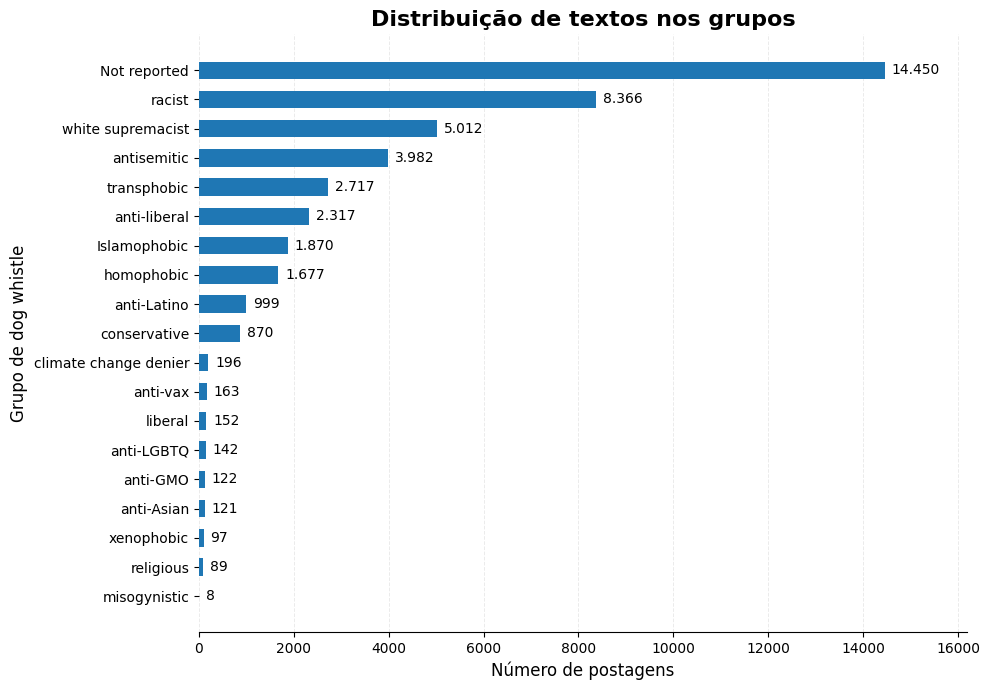

In [26]:
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    ingroup_counts.index,
    ingroup_counts.values,
    height=0.60
)

for bar, value in zip(bars, ingroup_counts.values):
    ax.text(
        value + ingroup_counts.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}".replace(",", "."),
        va="center",
        fontsize=10
    )

ax.set_xlabel("Número de postagens", fontsize=12)
ax.set_ylabel("Grupo de dog whistle", fontsize=12)

ax.set_title(
    "Distribuição de textos nos grupos",
    fontsize=16,
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)
ax.set_xlim(0, ingroup_counts.max() * 1.12)

plt.tight_layout()

plt.savefig(
    "ingroup_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [27]:
ingroup_labels_pt = {
    "misogynistic": "Misógino",
    "religious": "Religioso",
    "xenophobic": "Xenófobo",
    "anti-Asian": "Anti-asiático",
    "anti-GMO": "Anti-OGM",
    "anti-LGBTQ": "Anti-LGBTQIA+",
    "liberal": "Liberal",
    "anti-vax": "Antivacina",
    "climate change denier": "Negacionista climático",
    "conservative": "Conservador",
    "anti-Latino": "Anti-latino",
    "homophobic": "Homofóbico",
    "Islamophobic": "Islamofóbico",
    "anti-liberal": "Antiliberal",
    "transphobic": "Transfóbico",
    "antisemitic": "Antissemita",
    "white supremacist": "Supremacista branco",
    "racist": "Racista",
    "Not reported": "Não informado"
}

ingroup_counts_pt = ingroup_counts.rename(index=ingroup_labels_pt)

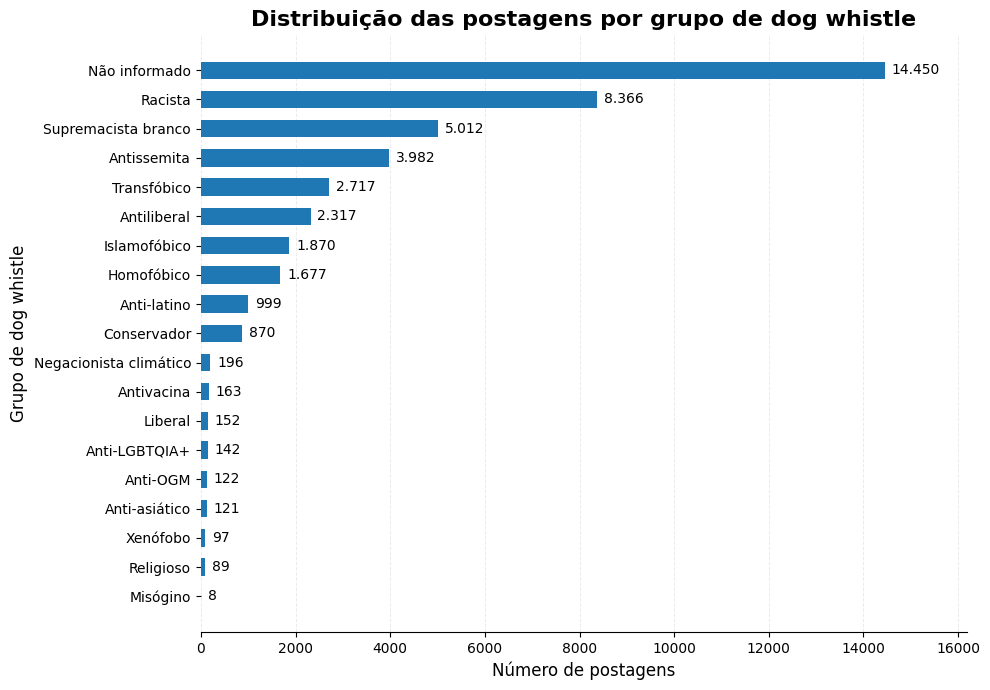

In [28]:
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    ingroup_counts_pt.index,
    ingroup_counts_pt.values,
    height=0.60
)

for bar, value in zip(bars, ingroup_counts_pt.values):
    ax.text(
        value + ingroup_counts_pt.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{value:,}".replace(",", "."),
        va="center",
        fontsize=10
    )

ax.set_xlabel("Número de postagens", fontsize=12)
ax.set_ylabel("Grupo de dog whistle", fontsize=12)

ax.set_title(
    "Distribuição das postagens por grupo de dog whistle",
    fontsize=16,
    fontweight="bold"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.set_axisbelow(True)
ax.set_xlim(0, ingroup_counts_pt.max() * 1.12)

plt.tight_layout()

plt.savefig(
    "ingroup_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

E a relação entre tipo (formal x informal) e classe (com dog whistle, sem dog whistle, com dog whistle sem o sentido)

In [24]:
pd.crosstab(
    df_geral["type"],
    df_geral["label"],
    margins=True
)

label,0,1,2,All
type,,,,
Formal,2223,2994,0,5217
Informal,12227,11456,14450,38133
All,14450,14450,14450,43350


Visualizando mais alguns detalhes do dataset...

In [29]:
auditoria = pd.DataFrame({
    "métrica": [
        "Duplicatas completas",
        "Conteúdos duplicados",
        "Dog whistles únicos",
    ],
    "valor": [
        int(df_geral.duplicated().sum()),
        int(df_geral["content"].duplicated().sum()),
        int(df_geral["dog_whistle"].replace("", np.nan).nunique(dropna=True)),
    ]
})

display(auditoria)

,métrica,valor
0,Duplicatas completas,1264
1,Conteúdos duplicados,1283
2,Dog whistles únicos,696


Retirando essas duplicatas para evitar que um mesmo texto apareça no treino e no teste. Por isso, a deduplicação será feita antes da divisão.

In [30]:
duplicate_contents = df_geral[df_geral["content"].duplicated(keep=False)].sort_values("content")

print("Número de linhas envolvidas em conteúdos repetidos:",
      len(duplicate_contents))

display(duplicate_contents.head(20))

df_model = df_geral.drop_duplicates(subset="content").copy()

print("Antes da deduplicação:", len(df_geral))
print("Depois da deduplicação:", len(df_model))

Número de linhas envolvidas em conteúdos repetidos: 1376


,label,content,dog_whistle,ingroup,type
40913,2,&amp;#3232;,None,None,Informal
40847,2,&amp;#3232;,None,None,Informal
40841,2,&amp;#3232;_&amp;#3232;,None,None,Informal
41410,2,&amp;#3232;_&amp;#3232;,None,None,Informal
41196,2,&amp;#3232;_&amp;#3232;,None,None,Informal
41171,2,&amp;#3232;_&amp;#3232;,None,None,Informal
41113,2,&amp;#3232;_&amp;#3232;,None,None,Informal
40910,2,&amp;#3232;_&amp;#3232;,None,None,Informal
40898,2,&amp;#3232;_&amp;#3232;,None,None,Informal
40889,2,&amp;#3232;_&amp;#3232;,None,None,Informal


Antes da deduplicação: 43350
Depois da deduplicação: 42067


## Pré-processamento

Serão mantidas duas versões:

- `content_original`: texto original;
- `content_clean`: versão normalizada para aplicação do BoW/TF-IDF (sem URLs, @s, #s, pontuações repetidas e espaços vazios).

### Aqui usamos Regex

Definindo as especificidades do que será desconsiderado...

In [31]:
URL_RE = re.compile(r"https?://\S+|www\.\S+", re.IGNORECASE)
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
REPEATED_PUNCT_RE = re.compile(r"([!?.,])\1{1,}")
MULTISPACE_RE = re.compile(r"\s+")

In [32]:
def normalize_text(text):
    text = str(text)
    text = URL_RE.sub(" URLTOKEN ", text)
    text = MENTION_RE.sub(" MENTIONTOKEN ", text)
    text = HASHTAG_RE.sub(r" \1 ", text)
    text = REPEATED_PUNCT_RE.sub(r" \1 ", text)
    text = text.lower()
    text = MULTISPACE_RE.sub(" ", text).strip()
    return text

Assim, obtemos tanto os valores do conteúdo original, quanto os do conteúdo já limpo/normalizado.

In [33]:
df_model["content_original"] = df_model["content"]
df_model["content_clean"] = df_model["content"].map(normalize_text)

display(df_model[["content_original", "content_clean"]].head(10))

,content_original,content_clean
0,Although I believe we must be extremely carefu...,although i believe we must be extremely carefu...
1,Good. Swedish cuckolds are an infestation on s...,good. swedish cuckolds are an infestation on s...
2,"Ah, gotcha, you're not an SJW, just didn't lik...","ah, gotcha, you're not an sjw, just didn't lik..."
3,It is currently fashionable to say that all of...,it is currently fashionable to say that all of...
4,You may be aware that corporate logos hint at ...,you may be aware that corporate logos hint at ...
5,as we grow energy sources that are American pr...,as we grow energy sources that are american pr...
6,Even if it were possible to alter every cell o...,even if it were possible to alter every cell o...
7,I think he'll probably be dropped by sponsors ...,i think he'll probably be dropped by sponsors ...
8,Thank you for your support fellow centipede an...,thank you for your support fellow centipede an...
9,Many special interests have been indignant bec...,many special interests have been indignant bec...


Agora, partimos para a parte legal hehehe

### Tokenização baseada em Regex

Esse Regex tenta encontrar uma sequência de letras, que pode ser seguida por apóstrofo/hífen e outra sequência de letras, OU então um número inteiro ou decimal para fazer a tokenização.

In [34]:
TOKEN_RE = re.compile(r"[a-zA-ZÀ-ÿ]+(?:['’-][a-zA-ZÀ-ÿ]+)?|\d+(?:[.,]\d+)?")

In [35]:
def tokenize(text):
    return TOKEN_RE.findall(str(text).lower())

In [36]:
df_model["tokens"] = df_model["content_clean"].map(tokenize)
df_model["token_count"] = df_model["tokens"].str.len()

display(df_model[["content_clean", "tokens"]].head())

,content_clean,tokens
0,although i believe we must be extremely carefu...,"[although, i, believe, we, must, be, extremely..."
1,good. swedish cuckolds are an infestation on s...,"[good, swedish, cuckolds, are, an, infestation..."
2,"ah, gotcha, you're not an sjw, just didn't lik...","[ah, gotcha, you're, not, an, sjw, just, didn'..."
3,it is currently fashionable to say that all of...,"[it, is, currently, fashionable, to, say, that..."
4,you may be aware that corporate logos hint at ...,"[you, may, be, aware, that, corporate, logos, ..."


### Frequência lexical - vamos usar o `en_core_web_sm`

Já tendo os tokens a partir do Regex, vamos desconsiderar as stop words do `en_core_web_sm` para calcular as frequências de palavras nas diferentes classes do nosso dataset.

In [37]:
nlp = spacy.load('en_core_web_sm')

In [38]:
STOPWORDS = nlp.Defaults.stop_words

In [39]:
def content_words(tokens):
    return [t for t in tokens if t not in STOPWORDS and len(t) > 1]

In [40]:
df_model["content_tokens"] = df_model["tokens"].map(content_words)

In [41]:
def top_words(data, label_value, n=20):
    words = data.loc[data["label"] == label_value, "content_tokens"].explode()
    return words.value_counts().head(n)

In [42]:
top_tables = {}
for label in [0, 1, 2]:
    top_tables[label] = top_words(df_model, label, 20).rename("frequência").to_frame()

In [43]:
display(top_tables[0])

,frequência
content_tokens,
people,2897
like,2357
it's,1796
single,1650
based,1546
don't,1427
terrorist,1306
think,1180
know,1059


In [44]:
display(top_tables[1])

,frequência
content_tokens,
people,2694
like,2057
it's,1497
don't,1212
want,1114
women,1086
think,1039
white,1010
black,861


In [45]:
display(top_tables[2])

,frequência
content_tokens,
urltoken,3551
like,3381
it's,2960
don't,2815
good,2705
i'm,2126
want,2067
learn,2051
know,1990


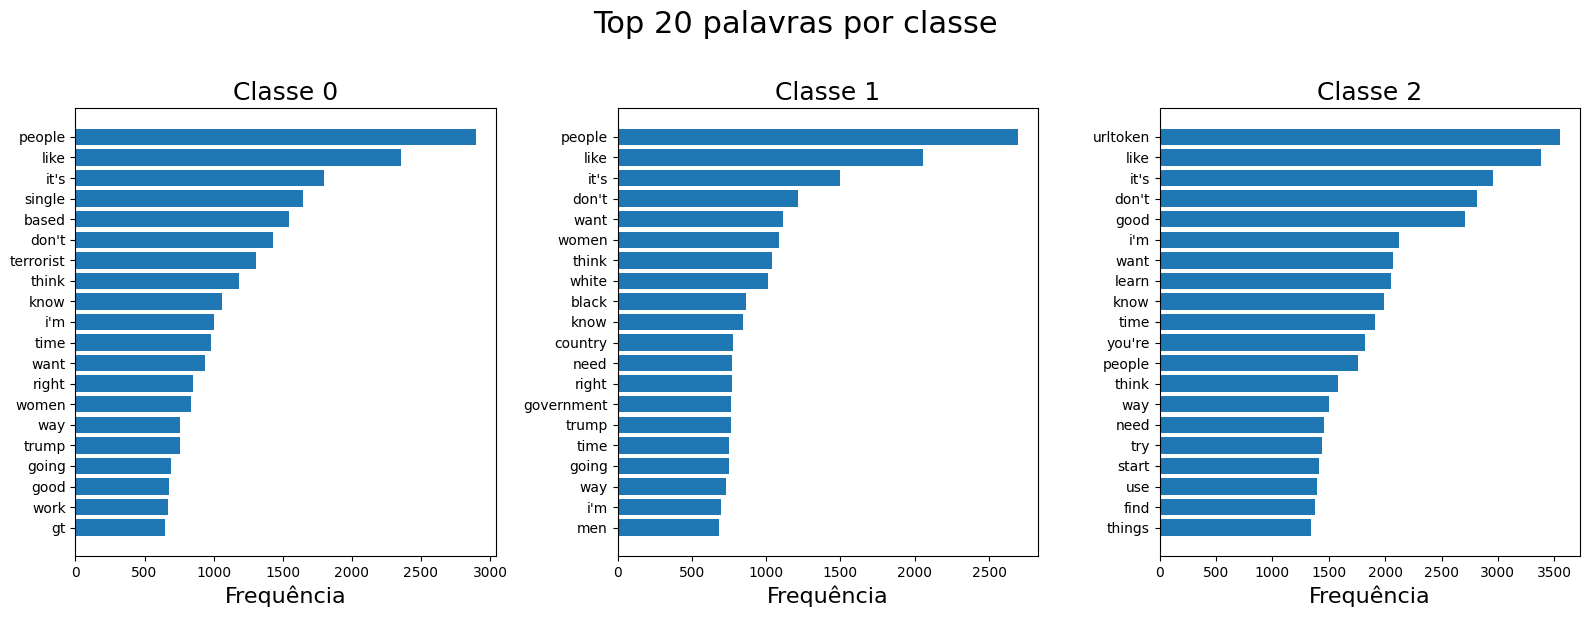

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

for ax, label in zip(axes, [0, 1, 2]):
    table = top_tables[label].sort_values("frequência")
    ax.barh(table.index, table["frequência"])
    ax.set_title(f"Classe {label}", fontsize=18)
    ax.set_xlabel("Frequência", fontsize=16)

fig.suptitle("Top 20 palavras por classe", y=1.02, fontsize=22)
plt.tight_layout()
plt.savefig("05_top_palavras_classes.png", dpi=250, bbox_inches="tight")
plt.show()

### Tokenização por NLTK

In [47]:
import nltk
from nltk.tokenize import TweetTokenizer

nltk.download("punkt")
nltk.download("punkt_tab")

tweet_tokenizer = TweetTokenizer(
    preserve_case=True,
    reduce_len=True,
    strip_handles=False
)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mariana25021\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mariana25021\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [48]:
def tokenize_tweet(text):
    return tweet_tokenizer.tokenize(text)

In [49]:
df_model["tokens_nltk"] = df_model["content_clean"].apply(tokenize_tweet)

In [50]:
df_model[["content", "tokens_nltk"]].head()

,content,tokens_nltk
0,Although I believe we must be extremely carefu...,"[although, i, believe, we, must, be, extremely..."
1,Good. Swedish cuckolds are an infestation on s...,"[good, ., swedish, cuckolds, are, an, infestat..."
2,"Ah, gotcha, you're not an SJW, just didn't lik...","[ah, ,, gotcha, ,, you're, not, an, sjw, ,, ju..."
3,It is currently fashionable to say that all of...,"[it, is, currently, fashionable, to, say, that..."
4,You may be aware that corporate logos hint at ...,"[you, may, be, aware, that, corporate, logos, ..."


In [51]:
df_model["content_tokenized_nltk"] = df_model["tokens_nltk"].apply(
    lambda tokens: " ".join(tokens)
)

### Comparando as tokenizações

In [52]:
comparacao = df_model[
    ["content", "tokens", "tokens_nltk"]
].sample(10, random_state=42)

display(comparacao)

,content,tokens,tokens_nltk
20204,I'm completely out. I lost a few fair weather ...,"[i'm, completely, out, i, lost, a, few, fair, ...","[i'm, completely, out, ., i, lost, a, few, fai..."
36196,"I've been told I give a ""deadly massage"" (minu...","[i've, been, told, i, give, a, deadly, massage...","[i've, been, told, i, give, a, "", deadly, mass..."
19429,Do I have my timelines crossed or did the rele...,"[do, i, have, my, timelines, crossed, or, did,...","[do, i, have, my, timelines, crossed, or, did,..."
6935,"A bill entitled the ""Transit Assistance Act of...","[a, bill, entitled, the, transit, assistance, ...","[a, bill, entitled, the, "", transit, assistanc..."
32347,Well I'd like to start out with simple things ...,"[well, i'd, like, to, start, out, with, simple...","[well, i'd, like, to, start, out, with, simple..."
31259,What about finding clients?,"[what, about, finding, clients]","[what, about, finding, clients, ?]"
5900,Because you can give the troons everything the...,"[because, you, can, give, the, troons, everyth...","[because, you, can, give, the, troons, everyth..."
32411,"i'd like to see some answers too, i'm 18 btw :...","[i'd, like, to, see, some, answers, too, i'm, ...","[i'd, like, to, see, some, answers, too, ,, i'..."
26485,Basically what you're seeing now --- massive a...,"[basically, what, you're, seeing, now, massive...","[basically, what, you're, seeing, now, -, -, -..."
41860,you're a dick,"[you're, a, dick]","[you're, a, dick]"


In [53]:
for i, row in comparacao.iterrows():
    print("=" * 80)
    print("TEXTO:")
    print(row["content"])
    print("\nREGEX:")
    print(row["tokens"])
    print("\nTWEETTOKENIZER:")
    print(row["tokens_nltk"])

TEXTO:
I'm completely out. I lost a few fair weather friends and had a couple family members hate me or think that I'm ignorant (one of them has now been converted to GC). I've had some people message me in private with supportive comments. I just started posting stuff on facebook (the Laurel Hubbard thing tipped me over the edge, it was just such a ridiculous situation) and then had a few brief real life convos out of it.

REGEX:
["i'm", 'completely', 'out', 'i', 'lost', 'a', 'few', 'fair', 'weather', 'friends', 'and', 'had', 'a', 'couple', 'family', 'members', 'hate', 'me', 'or', 'think', 'that', "i'm", 'ignorant', 'one', 'of', 'them', 'has', 'now', 'been', 'converted', 'to', 'gc', "i've", 'had', 'some', 'people', 'message', 'me', 'in', 'private', 'with', 'supportive', 'comments', 'i', 'just', 'started', 'posting', 'stuff', 'on', 'facebook', 'the', 'laurel', 'hubbard', 'thing', 'tipped', 'me', 'over', 'the', 'edge', 'it', 'was', 'just', 'such', 'a', 'ridiculous', 'situation', 'and', 

In [54]:
df_model["n_tokens_regex"] = df_model["tokens"].apply(len)
df_model["n_tokens_tweet"] = df_model["tokens_nltk"].apply(len)

print("Média de tokens - Regex:",
      df_model["n_tokens_regex"].mean())

print("Média de tokens - TweetTokenizer:",
      df_model["n_tokens_tweet"].mean())

print("Mediana de tokens - Regex:",
      df_model["n_tokens_regex"].median())

print("Mediana de tokens - TweetTokenizer:",
      df_model["n_tokens_tweet"].median())

Média de tokens - Regex: 45.79130910214658
Média de tokens - TweetTokenizer: 52.337485439893506
Mediana de tokens - Regex: 33.0
Mediana de tokens - TweetTokenizer: 37.0


### Analisando N-gramas

In [55]:
df_model["bigrams"] = df_model["tokens"].apply(
    lambda tokens: list(ngrams(tokens, 2))
)

df_model["trigrams"] = df_model["tokens"].apply(
    lambda tokens: list(ngrams(tokens, 3))
)

display(df_model[["tokens", "bigrams", "trigrams"]].head(10))

,tokens,bigrams,trigrams
0,"[although, i, believe, we, must, be, extremely...","[(although, i), (i, believe), (believe, we), (...","[(although, i, believe), (i, believe, we), (be..."
1,"[good, swedish, cuckolds, are, an, infestation...","[(good, swedish), (swedish, cuckolds), (cuckol...","[(good, swedish, cuckolds), (swedish, cuckolds..."
2,"[ah, gotcha, you're, not, an, sjw, just, didn'...","[(ah, gotcha), (gotcha, you're), (you're, not)...","[(ah, gotcha, you're), (gotcha, you're, not), ..."
3,"[it, is, currently, fashionable, to, say, that...","[(it, is), (is, currently), (currently, fashio...","[(it, is, currently), (is, currently, fashiona..."
4,"[you, may, be, aware, that, corporate, logos, ...","[(you, may), (may, be), (be, aware), (aware, t...","[(you, may, be), (may, be, aware), (be, aware,..."
5,"[as, we, grow, energy, sources, that, are, ame...","[(as, we), (we, grow), (grow, energy), (energy...","[(as, we, grow), (we, grow, energy), (grow, en..."
6,"[even, if, it, were, possible, to, alter, ever...","[(even, if), (if, it), (it, were), (were, poss...","[(even, if, it), (if, it, were), (it, were, po..."
7,"[i, think, he'll, probably, be, dropped, by, s...","[(i, think), (think, he'll), (he'll, probably)...","[(i, think, he'll), (think, he'll, probably), ..."
8,"[thank, you, for, your, support, fellow, centi...","[(thank, you), (you, for), (for, your), (your,...","[(thank, you, for), (you, for, your), (for, yo..."
9,"[many, special, interests, have, been, indigna...","[(many, special), (special, interests), (inter...","[(many, special, interests), (special, interes..."


análise interessante: ver quais bigramas e trigramas estão associados a classe 1 e 0 

## Etapa 1: identificar a presença ou ausência de termos associados a dog whistles

### Objetivo
> Identificar se um texto contém ou não um termo associado a dog whistle, independentemente de seu significado contextual.

Para isso, vamos criar uma nova coluna `presence` para identificar com `1` aqueles que possuírem dog whistles, e `0` os que não têm.

In [56]:
df_etapa1 = df_model.copy()

df_etapa1["presence"] = (
    df_etapa1["label"].isin([0, 1])
).astype(int)

In [57]:
df_etapa1

,label,content,dog_whistle,ingroup,type,content_original,content_clean,tokens,token_count,content_tokens,tokens_nltk,content_tokenized_nltk,n_tokens_regex,n_tokens_tweet,bigrams,trigrams,presence
0,1,Although I believe we must be extremely carefu...,institution of marriage,homophobic,Formal,Although I believe we must be extremely carefu...,although i believe we must be extremely carefu...,"[although, i, believe, we, must, be, extremely...",35,"[believe, extremely, careful, amending, consti...","[although, i, believe, we, must, be, extremely...",although i believe we must be extremely carefu...,35,38,"[(although, i), (i, believe), (believe, we), (...","[(although, i, believe), (i, believe, we), (be...",1
1,1,Good. Swedish cuckolds are an infestation on s...,cuckolds,white supremacist,Informal,Good. Swedish cuckolds are an infestation on s...,good. swedish cuckolds are an infestation on s...,"[good, swedish, cuckolds, are, an, infestation...",20,"[good, swedish, cuckolds, infestation, society...","[good, ., swedish, cuckolds, are, an, infestat...",good . swedish cuckolds are an infestation on ...,20,24,"[(good, swedish), (swedish, cuckolds), (cuckol...","[(good, swedish, cuckolds), (swedish, cuckolds...",1
2,0,"Ah, gotcha, you're not an SJW, just didn't lik...",SJW,anti-liberal,Informal,"Ah, gotcha, you're not an SJW, just didn't lik...","ah, gotcha, you're not an sjw, just didn't lik...","[ah, gotcha, you're, not, an, sjw, just, didn'...",18,"[ah, gotcha, you're, sjw, didn't, like, source...","[ah, ,, gotcha, ,, you're, not, an, sjw, ,, ju...","ah , gotcha , you're not an sjw , just didn't ...",18,23,"[(ah, gotcha), (gotcha, you're), (you're, not)...","[(ah, gotcha, you're), (gotcha, you're, not), ...",1
3,0,It is currently fashionable to say that all of...,special interest,antisemitic,Formal,It is currently fashionable to say that all of...,it is currently fashionable to say that all of...,"[it, is, currently, fashionable, to, say, that...",48,"[currently, fashionable, ills, nation, caused,...","[it, is, currently, fashionable, to, say, that...",it is currently fashionable to say that all of...,48,51,"[(it, is), (is, currently), (currently, fashio...","[(it, is, currently), (is, currently, fashiona...",1
4,0,You may be aware that corporate logos hint at ...,cabal,antisemitic,Informal,You may be aware that corporate logos hint at ...,you may be aware that corporate logos hint at ...,"[you, may, be, aware, that, corporate, logos, ...",38,"[aware, corporate, logos, hint, truth, alfa, r...","[you, may, be, aware, that, corporate, logos, ...",you may be aware that corporate logos hint at ...,38,43,"[(you, may), (may, be), (be, aware), (aware, t...","[(you, may, be), (may, be, aware), (be, aware,...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43345,2,"Awesome, thanks.\n\nI have TuxGuitar running; ...",None,None,Informal,"Awesome, thanks.\n\nI have TuxGuitar running; ...","awesome, thanks. i have tuxguitar running; onl...","[awesome, thanks, i, have, tuxguitar, running,...",17,"[awesome, thanks, tuxguitar, running, thing, i...","[awesome, ,, thanks, ., i, have, tuxguitar, ru...","awesome , thanks . i have tuxguitar running ; ...",17,21,"[(awesome, thanks), (thanks, i), (i, have), (h...","[(awesome, thanks, i), (thanks, i, have), (i, ...",0
43346,2,"This looks really cool, thanks! Taking a look ...",None,None,Informal,"This looks really cool, thanks! Taking a look ...","this looks really cool, thanks! taking a look ...","[this, looks, really, cool, thanks, taking, a,...",9,"[looks, cool, thanks, taking, look]","[this, looks, really, cool, ,, thanks, !, taki...","this looks really cool , thanks ! taking a loo...",9,12,"[(this, looks), (looks, really), (really, cool...","[(this, looks, really), (looks, really, cool),...",0
43347,2,Thanks a lot for the advice. We're actually go...,None,None,Informal,Thanks a lot for the advice. We're actually go...,thanks a lot for the advice. we're actually go...,"[thanks,

Divisão em treino e teste...

In [58]:
X1_train, X1_test, y1_train, y1_test = train_test_split(
    df_etapa1["content_clean"],
    df_etapa1["presence"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df_etapa1["presence"]
)

print("Treino:", len(X1_train))
print("Teste:", len(X1_test))

Treino: 33653
Teste: 8414


### Bag-Of-Words com Logistic Regression

In [63]:
bow = CountVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=30000
)

X1_bow_train = bow.fit_transform(X1_train)
X1_bow_test = bow.transform(X1_test)

bow_clf = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

bow_clf.fit(X1_bow_train, y1_train)
pred_bow = bow_clf.predict(X1_bow_test)

### Bag-Of-Words com Linear SVC

In [64]:
bow_clf = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

bow_clf.fit(X1_bow_train, y1_train)
pred_bow_svc = bow_clf.predict(X1_bow_test)

C:\Users\mariana25021\AppData\Roaming\Python\Python312\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


### TF-IDF com Logistic Regression e LinearSVC: bigramas

In [66]:
tfidf1 = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=30000,
    sublinear_tf=True
)

X1_tfidf_train = tfidf1.fit_transform(X1_train)
X1_tfidf_test = tfidf1.transform(X1_test)

tfidf_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

tfidf_lr.fit(X1_tfidf_train, y1_train)
pred_tfidf_lr = tfidf_lr.predict(X1_tfidf_test)

tfidf_svm = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

tfidf_svm.fit(X1_tfidf_train, y1_train)
pred_tfidf_svm = tfidf_svm.predict(X1_tfidf_test)

### TF-IDF com Logistic Regression e LinearSVC: trigramas

In [67]:
tfidf2 = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=3,
    max_features=30000,
    sublinear_tf=True
)

X1_tfidf2_train = tfidf2.fit_transform(X1_train)
X1_tfidf2_test = tfidf2.transform(X1_test)

tfidf_lr2 = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

tfidf_lr2.fit(X1_tfidf2_train, y1_train)
pred_tfidf2_lr = tfidf_lr2.predict(X1_tfidf2_test)

tfidf2_svm = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

tfidf2_svm.fit(X1_tfidf2_train, y1_train)
pred_tfidf2_svm = tfidf2_svm.predict(X1_tfidf2_test)

### Avaliação

In [68]:
def binary_metrics(y_true, y_pred, model_name):
    return {
        "modelo": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred)
    }

stage1_results = pd.DataFrame([
    binary_metrics(y1_test, pred_bow, "BoW + Logistic Regression"),
    binary_metrics(y1_test, pred_bow_svc, "BoW + Linear SVC"),
    binary_metrics(y1_test, pred_tfidf_lr, "TF-IDF 2-gram + Logistic Regression"),
    binary_metrics(y1_test, pred_tfidf_svm, "TF-IDF 2-gram + Linear SVC"),
    binary_metrics(y1_test, pred_tfidf2_lr, "TF-IDF 3-gram + Logistic Regression"),
    binary_metrics(y1_test, pred_tfidf2_svm, "TF-IDF 3-gram + Linear SVC")
])

display(stage1_results.round(4))

,modelo,accuracy,precision,recall,f1,balanced_accuracy
0,BoW + Logistic Regression,0.9565,0.9762,0.9599,0.9680,0.9545
1,BoW + Linear SVC,0.9544,0.9667,0.9667,0.9667,0.9472
2,TF-IDF 2-gram + Logistic Regression,0.9453,0.9708,0.9486,0.9596,0.9434
3,TF-IDF 2-gram + Linear SVC,0.9624,0.9765,0.9684,0.9724,0.9590
4,TF-IDF 3-gram + Logistic Regression,0.9457,0.9704,0.9496,0.9599,0.9434
5,TF-IDF 3-gram + Linear SVC,0.9605,0.9748,0.9673,0.9711,0.9566


### Similaridade dos cossenos

In [60]:
indices_amostra = np.random.choice(
    X1_tfidf_train.shape[0],
    size=1000
)

sim_bow = cosine_similarity(X1_bow_train[indices_amostra])
sim_tfidf = cosine_similarity(X1_tfidf_train[indices_amostra])
sim_tfidf2 = cosine_similarity(X1_tfidf2_train[indices_amostra])

print(sim_bow[:5, :5])
print(sim_tfidf[:5, :5])
print(sim_tfidf2[:5, :5])

[[1.         0.17143137 0.22929006 0.1396551  0.23664812]
 [0.17143137 1.         0.10088927 0.05745904 0.13819603]
 [0.22929006 0.10088927 1.         0.17611839 0.19253925]
 [0.1396551  0.05745904 0.17611839 1.         0.25586412]
 [0.23664812 0.13819603 0.19253925 0.25586412 1.        ]]
[[1.         0.02639483 0.02771088 0.01087578 0.05145091]
 [0.02639483 1.         0.01034078 0.00523304 0.02651179]
 [0.02771088 0.01034078 1.         0.00918096 0.04111095]
 [0.01087578 0.00523304 0.00918096 1.         0.03033202]
 [0.05145091 0.02651179 0.04111095 0.03033202 1.        ]]
[[1.         0.02226915 0.02451642 0.0103132  0.04491264]
 [0.02226915 1.         0.00947369 0.00513861 0.02396478]
 [0.02451642 0.00947369 1.         0.0094537  0.03896852]
 [0.0103132  0.00513861 0.0094537  1.         0.03081655]
 [0.04491264 0.02396478 0.03896852 0.03081655 1.        ]]


In [61]:
i, j = np.triu_indices_from(sim_bow, k=1)

valores_bow = sim_bow[i, j]
valores_tfidf = sim_tfidf[i, j]
valores_tfidf2 = sim_tfidf2[i, j]

print("Média BoW:", valores_bow.mean())
print("Média TF-IDF 2-gram:", valores_tfidf.mean())
print("Média TF-IDF 3-gram:", valores_tfidf2.mean())

Média BoW: 0.11590047145036719
Média TF-IDF 2-gram: 0.016067470332779287
Média TF-IDF 3-gram: 0.015417867843441336


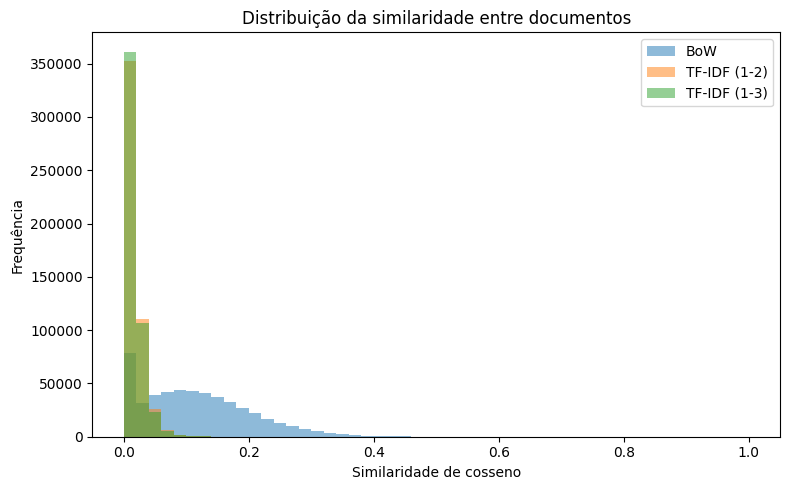

In [62]:
plt.figure(figsize=(8, 5))

plt.hist(
    valores_bow,
    bins=50,
    alpha=0.5,
    label="BoW"
)

plt.hist(
    valores_tfidf,
    bins=50,
    alpha=0.5,
    label="TF-IDF (1-2)"
)

plt.hist(
    valores_tfidf2,
    bins=50,
    alpha=0.5,
    label="TF-IDF (1-3)"
)

plt.xlabel("Similaridade de cosseno")
plt.ylabel("Frequência")
plt.title("Distribuição da similaridade entre documentos")
plt.legend()
plt.tight_layout()
plt.show()

### Matriz de Confusão

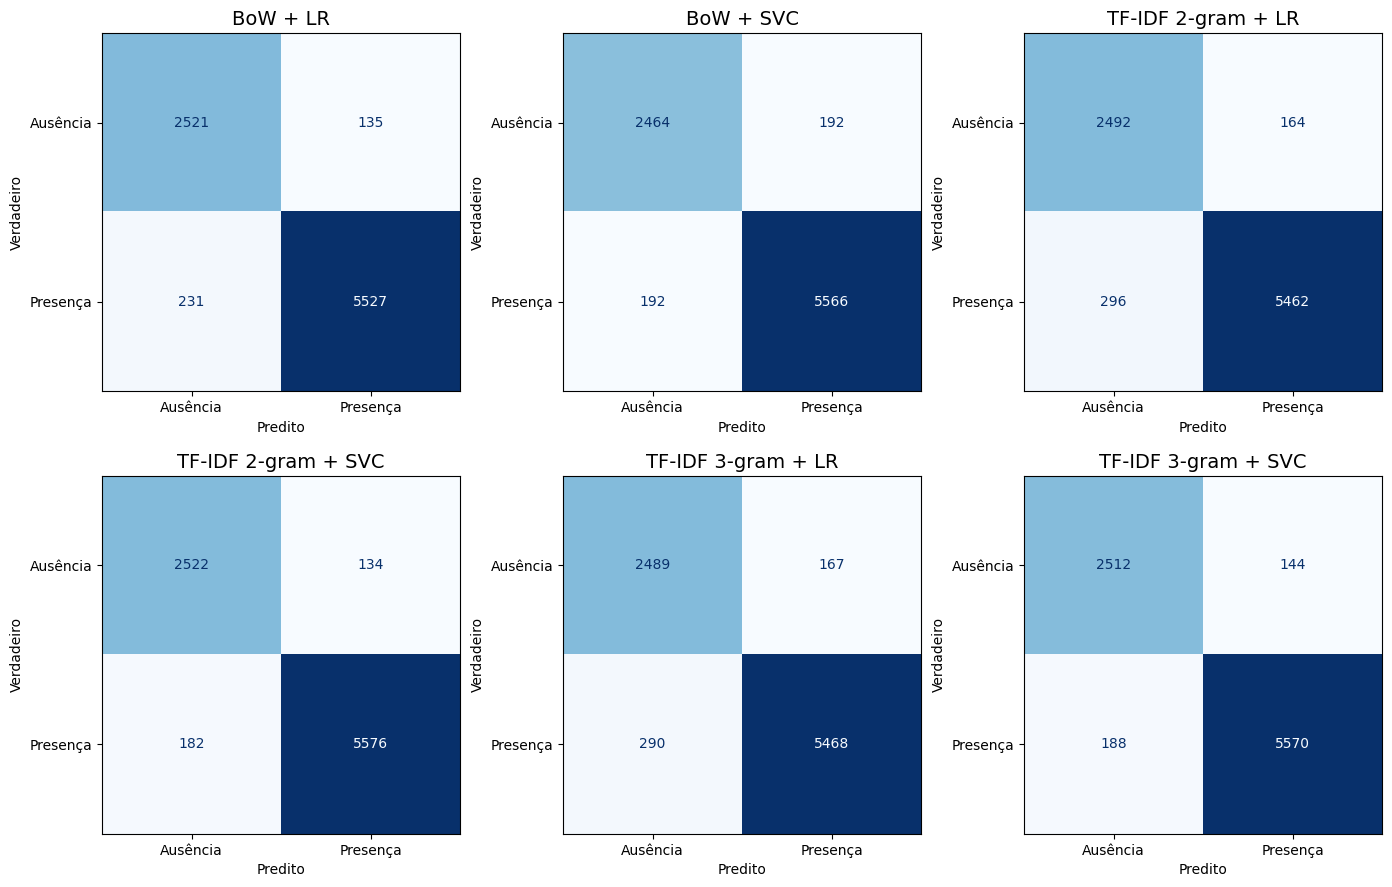

In [72]:
predictions_stage1 = {
    "BoW + LR": pred_bow,
    "BoW + SVC": pred_bow_svc,
    "TF-IDF 2-gram + LR": pred_tfidf_lr,
    "TF-IDF 2-gram + SVC": pred_tfidf_svm,
    "TF-IDF 3-gram + LR": pred_tfidf2_lr,
    "TF-IDF 3-gram + SVC": pred_tfidf2_svm
}

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for ax, (name, pred) in zip(
    axes.ravel(), predictions_stage1.items()
):
    cm = confusion_matrix(
        y1_test, pred, labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Ausência", "Presença"]
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
        cmap="Blues"
    )

    ax.set_title(name, fontsize=14)
    ax.set_xlabel("Predito", fontsize=10)
    ax.set_ylabel("Verdadeiro", fontsize=10)

plt.tight_layout()
plt.savefig(
    "matrizes_confusao_etapa1.png",
    dpi=350,
    bbox_inches="tight"
)
plt.show()

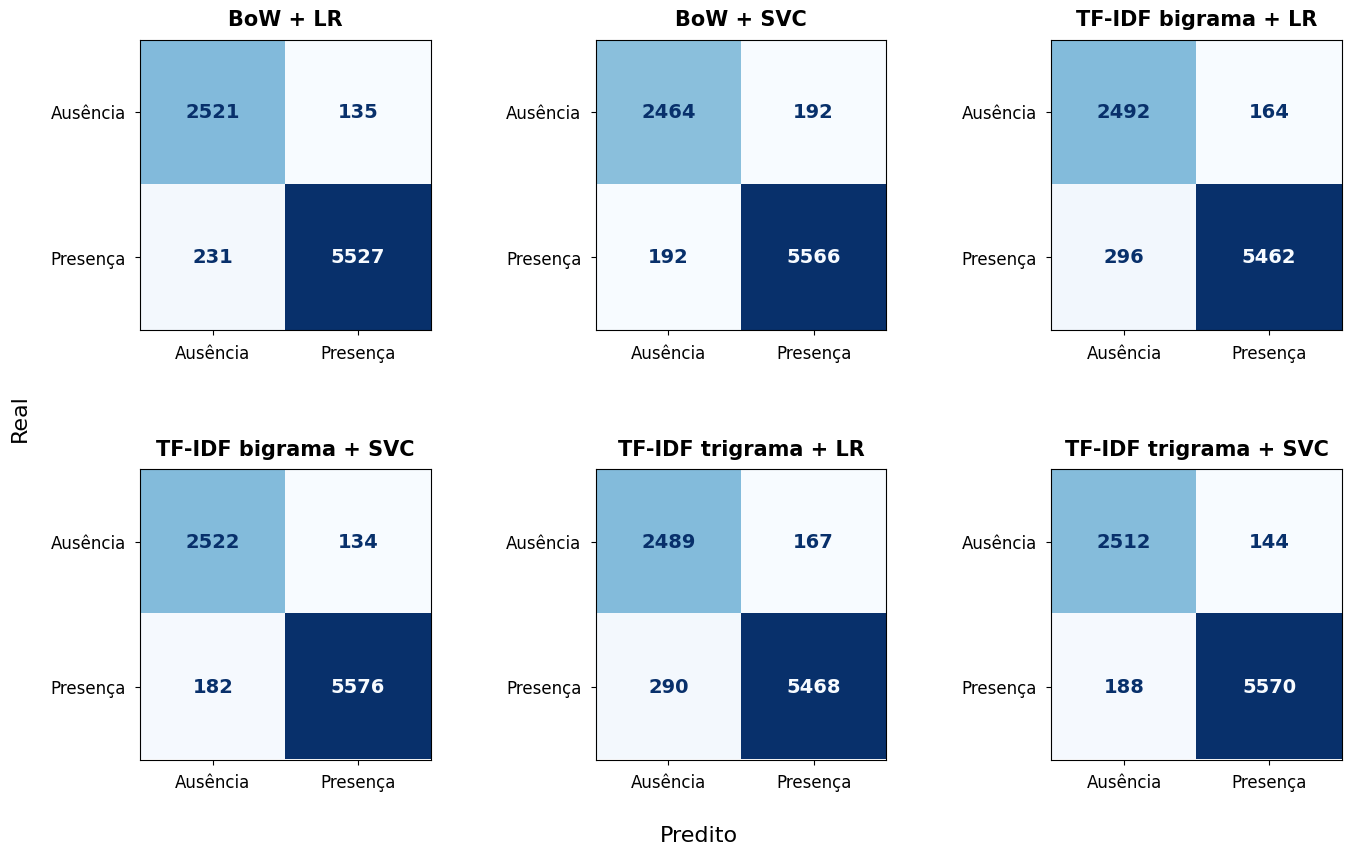

In [137]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


predictions_stage1 = {
    "BoW + LR": pred_bow,
    "BoW + SVC": pred_bow_svc,
    "TF-IDF bigrama + LR": pred_tfidf_lr,
    "TF-IDF bigrama + SVC": pred_tfidf_svm,
    "TF-IDF trigrama + LR": pred_tfidf2_lr,
    "TF-IDF trigrama + SVC": pred_tfidf2_svm
}


# =========================================================
# FIGURA
# =========================================================

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 9)
)


# =========================================================
# PLOTAR MATRIZES
# =========================================================

for ax, (name, pred) in zip(
    axes.ravel(),
    predictions_stage1.items()
):

    cm = confusion_matrix(
        y1_test,
        pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Ausência", "Presença"]
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
        cmap="Blues"
    )

    # -----------------------------------------------------
    # NÚMEROS DAS CÉLULAS
    # -----------------------------------------------------

    for text in disp.text_.ravel():
        text.set_fontsize(14)
        text.set_fontweight("bold")

    # -----------------------------------------------------
    # TÍTULO
    # -----------------------------------------------------

    ax.set_title(
        name,
        fontsize=15,
        fontweight="bold",
        pad=10
    )

    # -----------------------------------------------------
    # REMOVER "REAL" E "PREDITO" DOS SUBGRÁFICOS
    # -----------------------------------------------------

    ax.set_xlabel("")
    ax.set_ylabel("")

    # -----------------------------------------------------
    # RÓTULOS "AUSÊNCIA" E "PRESENÇA"
    # -----------------------------------------------------

    ax.tick_params(
        axis="both",
        labelsize=12,
        pad=7
    )


# =========================================================
# EIXO Y — REAL
# APARECE UMA ÚNICA VEZ
# =========================================================

fig.text(
    0.035,
    0.50,
    "Real",
    rotation=90,
    va="center",
    ha="center",
    fontsize=16,
    fontweight="normal"
)


# =========================================================
# EIXO X — PREDITO
# APARECE UMA ÚNICA VEZ
# =========================================================

fig.text(
    0.52,
    0.035,
    "Predito",
    va="center",
    ha="center",
    fontsize=16,
    fontweight="normal"
)


# =========================================================
# AJUSTES DE ESPAÇAMENTO
# =========================================================

plt.subplots_adjust(
    left=0.11,
    right=0.99,
    bottom=0.12,
    top=0.92,
    wspace=0.42,
    hspace=0.48
)


# =========================================================
# SALVAR
# =========================================================

plt.savefig(
    "matrizes_confusao_etapa1_nova.png",
    dpi=350,
    bbox_inches="tight"
)

plt.show()

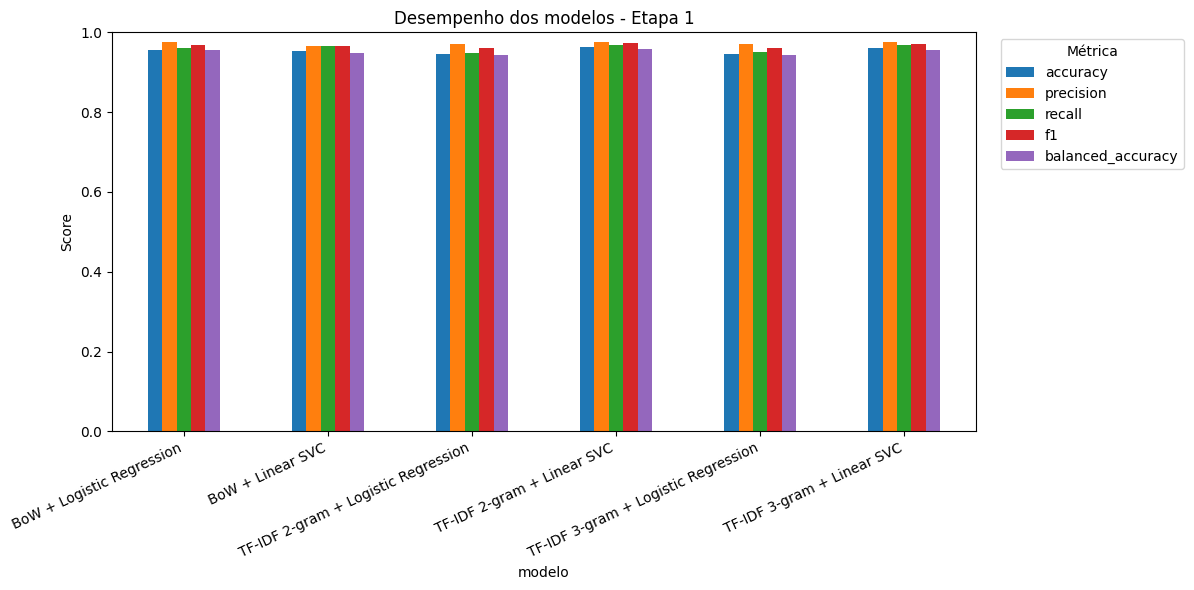

In [77]:
metrics_plot = stage1_results.set_index("modelo")[
    ["accuracy", "precision", "recall", "f1", "balanced_accuracy"]
]

ax = metrics_plot.plot(kind="bar", figsize=(12, 6))
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Desempenho dos modelos - Etapa 1")
ax.legend(title="Métrica", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig("comparacao_modelos_etapa1.png", dpi=250)
plt.show()

In [78]:
feature_names = np.array(tfidf1.get_feature_names_out())
coef = tfidf_lr.coef_[0]

top_positive = np.argsort(coef)[-25:][::-1]
top_negative = np.argsort(coef)[:25]

print("Termos mais associados à presença 2-gram:")
display(pd.DataFrame({
    "termo": feature_names[top_positive],
    "coeficiente": coef[top_positive]
}))

Termos mais associados à presença 2-gram:


,termo,coeficiente
0,single,10.670583
1,based,8.689751
2,sjw,8.178161
3,the,7.682371
4,they,7.118662
5,we,6.518219
6,trump,6.310686
7,sjws,5.974606
8,to,5.946967
9,welfare,5.848998


In [79]:
print("Termos mais associados à ausência 2-gram:")
display(pd.DataFrame({
    "termo": feature_names[top_negative],
    "coeficiente": coef[top_negative]
}))

Termos mais associados à ausência 2-gram:


,termo,coeficiente
0,urltoken,-11.385562
1,learn,-5.713946
2,thanks,-5.577487
3,try,-4.018498
4,practice,-3.974766
5,you,-3.780294
6,advice,-3.696498
7,how to,-3.575968
8,to learn,-3.457165
9,book,-3.343851


In [80]:
feature_names = np.array(tfidf2.get_feature_names_out())
coef = tfidf_lr2.coef_[0]

top_positive = np.argsort(coef)[-25:][::-1]
top_negative = np.argsort(coef)[:25]

print("Termos mais associados à presença 3-gram:")
display(pd.DataFrame({
    "termo": feature_names[top_positive],
    "coeficiente": coef[top_positive]
}))

Termos mais associados à presença 3-gram:


,termo,coeficiente
0,single,11.007899
1,based,8.887104
2,sjw,8.446048
3,the,7.807392
4,they,7.173923
5,trump,6.579153
6,we,6.386002
7,to,6.308205
8,sjws,6.079172
9,welfare,5.938972


In [81]:
print("Termos mais associados à ausência 3-gram:")
display(pd.DataFrame({
    "termo": feature_names[top_negative],
    "coeficiente": coef[top_negative]
}))

Termos mais associados à ausência 3-gram:


,termo,coeficiente
0,urltoken,-11.228668
1,learn,-5.759514
2,thanks,-5.277454
3,practice,-4.121330
4,try,-3.939583
5,advice,-3.833074
6,how to,-3.476179
7,learning,-3.424601
8,to learn,-3.412414
9,you,-3.361960


In [82]:
errors = df_etapa1.loc[X1_test.index].copy()

errors["prediction"] = pred_tfidf2_svm

errors["correct"] = (
    errors["presence"] == errors["prediction"]
)

In [83]:
false_positive = errors[
    (errors["presence"] == 0) &
    (errors["prediction"] == 1)
]

display(
    false_positive[
        ["content", "presence", "prediction"]
    ].head(20)
)

,content,presence,prediction
34761,"lol, is that bad?, damn, I don't know what to ...",0,1
41494,"All three good points. As far as number four, ...",0,1
35917,Those people also weren't spoiled their whole ...,0,1
36370,Grin to show fangs!,0,1
35886,"I'm no expert, but I'll take a crack at this o...",0,1
34084,"They didn't exactly *invade* Russia, though. T...",0,1
31475,real estate,0,1
32958,So I should just convince myself that being wi...,0,1
41098,"These days, the vast majority of theaters stil...",0,1
39561,I'm pretty sure the US government doesn't reco...,0,1


In [84]:
false_negative = errors[
    (errors["presence"] == 1) &
    (errors["prediction"] == 0)
]

display(
    false_negative[
        ["content", "presence", "prediction"]
    ].head(20)
)

,content,presence,prediction
8286,No THIS guys name was probably something like ...,1,0
12551,Their specific heat minus the energy required ...,1,0
3838,"Work in tv, can confirm. A lot of union people...",1,0
23247,I'm French and GC but my account is locked. I ...,1,0
27875,karma is mostly useless....but you can have so...,1,0
20906,Nope then India will loose a lot of soft power...,1,0
11158,I was thinking arson before I clicked the link...,1,0
28810,I remember looking at naked women as a kid. I ...,1,0
2677,"Say what you want, I still like the no more br...",1,0
18682,"If you’re going to be 6 inches from my face, I...",1,0


#### Análise do desempenho por tipo de texto

In [85]:
from sklearn.metrics import classification_report

for tipo in errors["type"].unique():

    subset = errors[errors["type"] == tipo]

    print(f"===== {tipo} =====")

    print(
        classification_report(
            subset["presence"],
            subset["prediction"],
            zero_division=0
        )
    )

===== Informal =====
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      2656
           1       0.97      0.96      0.97      4719

    accuracy                           0.96      7375
   macro avg       0.95      0.95      0.95      7375
weighted avg       0.96      0.96      0.96      7375

===== Formal =====
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       1.00      0.99      1.00      1039

    accuracy                           0.99      1039
   macro avg       0.50      0.50      0.50      1039
weighted avg       1.00      0.99      1.00      1039



## Etapa 2: Interpretação contextual

### Objetivo
>Dado que um termo associado a dog whistle está presente, é possível determinar, a partir do contexto, se ele está sendo empregado com significado de dog whistle?

In [86]:
df_etapa2 = df_geral[df_geral.label.isin([0, 1])]

In [87]:
df_etapa2

,label,content,dog_whistle,ingroup,type
0,1,Although I believe we must be extremely carefu...,institution of marriage,homophobic,Formal
1,1,Good. Swedish cuckolds are an infestation on s...,cuckolds,white supremacist,Informal
2,0,"Ah, gotcha, you're not an SJW, just didn't lik...",SJW,anti-liberal,Informal
3,0,It is currently fashionable to say that all of...,special interest,antisemitic,Formal
4,0,You may be aware that corporate logos hint at ...,cabal,antisemitic,Informal
...,...,...,...,...,...
28895,0,Like is your system more based around freedom ...,based,white supremacist,Informal
28896,0,Apple maps took me to a flyover and as I got h...,Google,racist,Informal
28897,0,Sometimes it feels we're back in 1600s Scotlan...,freedom of religion,homophobic,Informal
28898,1,True. Firefox is less of an enemy and globalis...,octopus,antisemitic,Informal


In [88]:
def normalize_for_match(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text).strip()
    return text

def context_window(text, term, window=8):
    text = normalize_for_match(text)
    term = normalize_for_match(term)

    if not term:
        return text

    # primeira ocorrência do termo
    start = text.find(term)

    if start == -1:
        # retorno da falha: considerou o texto inteiro
        return text

    before = text[:start].split()
    after = text[start + len(term):].split()

    left = before[-window:]
    right = after[:window]

    return " ".join(left + [term] + right)

In [89]:
df_etapa2["context_window"] = [
    context_window(text, term, window=8)
    for text, term in zip(df_etapa2["content"], df_etapa2["dog_whistle"])
]

display(df_etapa2[["label", "dog_whistle", "context_window"]].sample(10, random_state=RANDOM_STATE))

C:\Users\mariana25021\AppData\Local\Temp\ipykernel_2012\1032242189.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_etapa2["context_window"] = [


,label,dog_whistle,context_window
24732,1,surgical wound,"kind of vagina, and it ain't a gaping surgical..."
16024,0,based,well based on his pics he’s in the army and
8178,0,SJWs,which is why sjws are the antithesis to actual...
8510,0,blue,as he did i saw flickers of deep blue and purp...
16833,1,traditional marriage,i read the plot. a couple in a traditional mar...
15496,1,climate alarmist,any and all debate. let me try: ' climate alar...
6909,1,ghettos,passed that act cities have become massive aba...
25394,0,political correctness,oppressed and silenced for too long by gynocen...
23896,1,entitlement program,a congress obsessed and being overly protectiv...
23901,0,deep state,lot of people to the wickedness of the deep st...


In [90]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    df_etapa2["content"],
    df_etapa2["label"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=df_etapa2["label"]
)

train2_idx = X2_train.index
test2_idx = X2_test.index

print("Treino:", len(X2_train))
print("Teste:", len(X2_test))

Treino: 23120
Teste: 5780


### TF-IDF simples
Primeiro testamos se o texto completo consegue distinguir o uso literal/convencional do uso como dog whistle.

In [91]:
tfidf2_full = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=3,
    max_features=30000,
    sublinear_tf=True
)

X2_full_train = tfidf2_full.fit_transform(X2_train)
X2_full_test = tfidf2_full.transform(X2_test)

model2_full = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model2_full.fit(X2_full_train, y2_train)
pred2_full = model2_full.predict(X2_full_test)

In [93]:
model2_svc_full = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model2_svc_full.fit(X2_full_train, y2_train)
pred2_svc_full = model2_svc_full.predict(X2_full_test)

In [92]:
tfidf3_full = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=3,
    max_features=30000,
    sublinear_tf=True
)

X3_full_train = tfidf3_full.fit_transform(X2_train)
X3_full_test = tfidf3_full.transform(X2_test)

model3_full = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model3_full.fit(X3_full_train, y2_train)
pred3_full = model3_full.predict(X3_full_test)

In [94]:
model3_svc_full = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model3_svc_full.fit(X3_full_train, y2_train)
pred3_svc_full = model3_svc_full.predict(X3_full_test)

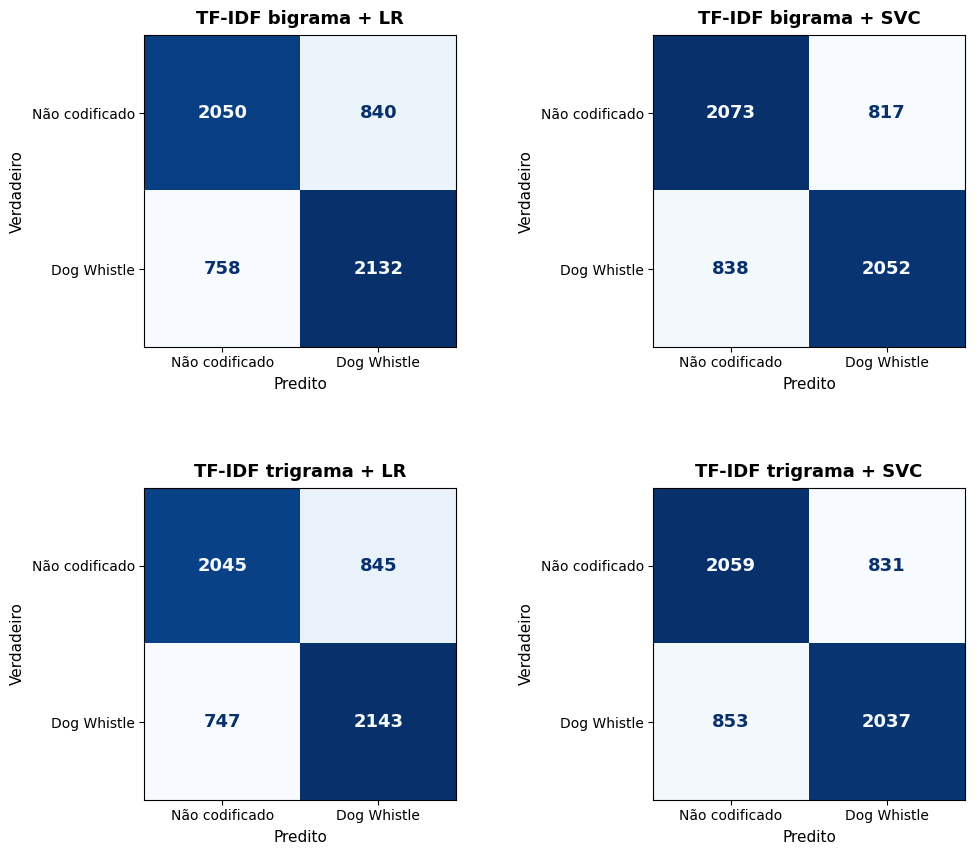

In [104]:
predictions_stage1 = {
    "TF-IDF bigrama + LR": pred2_full,
    "TF-IDF bigrama + SVC": pred2_svc_full,
    "TF-IDF trigrama + LR": pred3_full,
    "TF-IDF trigrama + SVC": pred3_svc_full
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 9)
)

for ax, (name, pred) in zip(
    axes.ravel(), predictions_stage1.items()
):

    cm = confusion_matrix(
        y2_test,
        pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Não codificado", "Dog Whistle"]
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
        cmap="Blues"
    )

    # Números dentro das células
    for text in disp.text_.ravel():
        text.set_fontsize(13)
        text.set_fontweight("bold")

    # Título
    ax.set_title(
        name,
        fontsize=13,
        fontweight="bold",
        pad=8
    )

    # Eixos
    ax.set_xlabel(
        "Predito",
        fontsize=11,
        labelpad=5
    )

    ax.set_ylabel(
        "Verdadeiro",
        fontsize=11,
        labelpad=5
    )

    # Rótulos Ausência / Presença
    ax.tick_params(
        axis="both",
        labelsize=10,
        pad=3
    )

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.93,
    wspace=0.30,
    hspace=0.45
)

plt.savefig(
    "matrizes_confusao_etapa2.png",
    dpi=350,
    bbox_inches="tight"
)

plt.show()

Agora usamos somente as palavras próximas ao termo candidato. Essa comparação permite investigar se o contexto local é suficiente para distinguir os dois sentidos.

In [98]:
# Representações textuais
X2_full = df_etapa2["content"]
X2_context = df_etapa2["context_window"]

# Índices já definidos pela divisão original
X2c_train = X2_context.loc[train2_idx]
X2c_test = X2_context.loc[test2_idx]

# Rótulos correspondentes
y2c_train = df_etapa2.loc[train2_idx, "label"]
y2c_test = df_etapa2.loc[test2_idx, "label"]

tfidf2_context = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_features=30000,
    sublinear_tf=True
)

X2_context_train = tfidf2_context.fit_transform(X2c_train)
X2_context_test = tfidf2_context.transform(X2c_test)

model2_context = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model2_context.fit(X2_context_train, y2c_train)
pred2_context = model2_context.predict(X2_context_test)

In [99]:
model2_svc_context = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model2_svc_context.fit(X2_context_train, y2c_train)
pred2_svc_context = model2_svc_context.predict(X2_context_test)

In [100]:
X3_full = df_etapa2["content"]
X3_context = df_etapa2["context_window"]

X3c_train = X3_context.loc[train2_idx]
X3c_test = X3_context.loc[test2_idx]

y3c_train = df_etapa2.loc[train2_idx, "label"]
y3c_test = df_etapa2.loc[test2_idx, "label"]

tfidf3_context = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=2,
    max_features=30000,
    sublinear_tf=True
)

X3_context_train = tfidf3_context.fit_transform(X3c_train)
X3_context_test = tfidf3_context.transform(X3c_test)

model3_context = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model3_context.fit(X3_context_train, y3c_train)
pred3_context = model3_context.predict(X3_context_test)

In [101]:
model3_svc_context = LinearSVC(
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model3_svc_context.fit(X3_context_train, y3c_train)
pred3_svc_context = model3_svc_context.predict(X3_context_test)

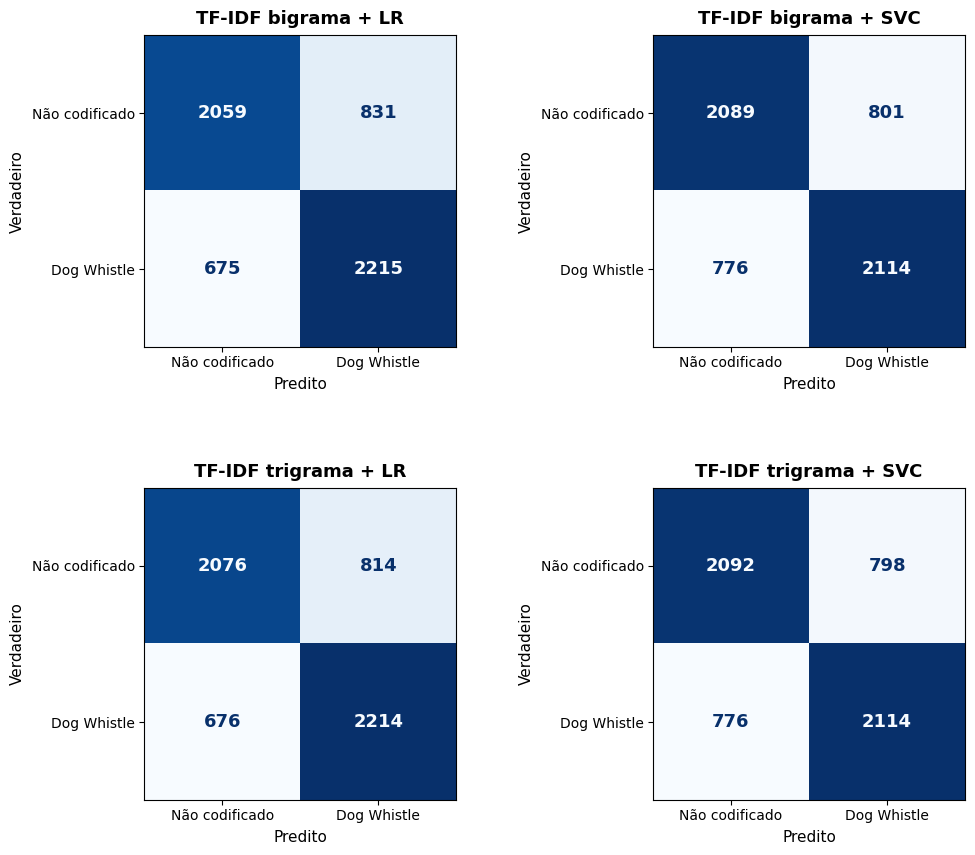

In [105]:
predictions_stage1 = {
    "TF-IDF bigrama + LR": pred2_context,
    "TF-IDF bigrama + SVC": pred2_svc_context,
    "TF-IDF trigrama + LR": pred3_context,
    "TF-IDF trigrama + SVC": pred3_svc_context
}

fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 9)
)

for ax, (name, pred) in zip(
    axes.ravel(), predictions_stage1.items()
):

    cm = confusion_matrix(
        y2_test,
        pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Não codificado", "Dog Whistle"]
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
        cmap="Blues"
    )

    # Números dentro das células
    for text in disp.text_.ravel():
        text.set_fontsize(13)
        text.set_fontweight("bold")

    # Título
    ax.set_title(
        name,
        fontsize=13,
        fontweight="bold",
        pad=8
    )

    # Eixos
    ax.set_xlabel(
        "Predito",
        fontsize=11,
        labelpad=5
    )

    ax.set_ylabel(
        "Verdadeiro",
        fontsize=11,
        labelpad=5
    )

    # Rótulos Ausência / Presença
    ax.tick_params(
        axis="both",
        labelsize=10,
        pad=3
    )

plt.subplots_adjust(
    left=0.08,
    right=0.98,
    bottom=0.08,
    top=0.93,
    wspace=0.30,
    hspace=0.45
)

plt.savefig(
    "matrizes_confusao_etapa2_1.png",
    dpi=350,
    bbox_inches="tight"
)

plt.show()

### Avaliação dos resultados

In [106]:
stage2_results = pd.DataFrame([
    binary_metrics(y2_test, pred2_full, "TF-IDF 2-gram texto completo + LR"),
    binary_metrics(y2_test, pred3_full, "TF-IDF 3-gram texto completo + LR"),
    binary_metrics(y2_test, pred2_svc_full, "TF-IDF 2-gram texto completo + SVC"),
    binary_metrics(y2_test, pred3_svc_full, "TF-IDF 3-gram texto completo + SVC"),
    binary_metrics(y2c_test, pred2_context, "TF-IDF 2-gram janela contextual + LR"),
    binary_metrics(y3c_test, pred3_context, "TF-IDF 3-gram janela contextual + LR"),
    binary_metrics(y2c_test, pred2_svc_context, "TF-IDF 2-gram janela contextual + SVC"),
    binary_metrics(y3c_test, pred3_svc_context, "TF-IDF 3-gram janela contextual + SVC") 
])

display(stage2_results.round(4))

,modelo,accuracy,precision,recall,f1,balanced_accuracy
0,TF-IDF 2-gram texto completo + LR,0.7235,0.7174,0.7377,0.7274,0.7235
1,TF-IDF 3-gram texto completo + LR,0.7246,0.7172,0.7415,0.7292,0.7246
2,TF-IDF 2-gram texto completo + SVC,0.7137,0.7152,0.7100,0.7126,0.7137
3,TF-IDF 3-gram texto completo + SVC,0.7087,0.7103,0.7048,0.7075,0.7087
4,TF-IDF 2-gram janela contextual + LR,0.7394,0.7272,0.7664,0.7463,0.7394
5,TF-IDF 3-gram janela contextual + LR,0.7422,0.7312,0.7661,0.7482,0.7422
6,TF-IDF 2-gram janela contextual + SVC,0.7272,0.7252,0.7315,0.7283,0.7272
7,TF-IDF 3-gram janela contextual + SVC,0.7277,0.7260,0.7315,0.7287,0.7277


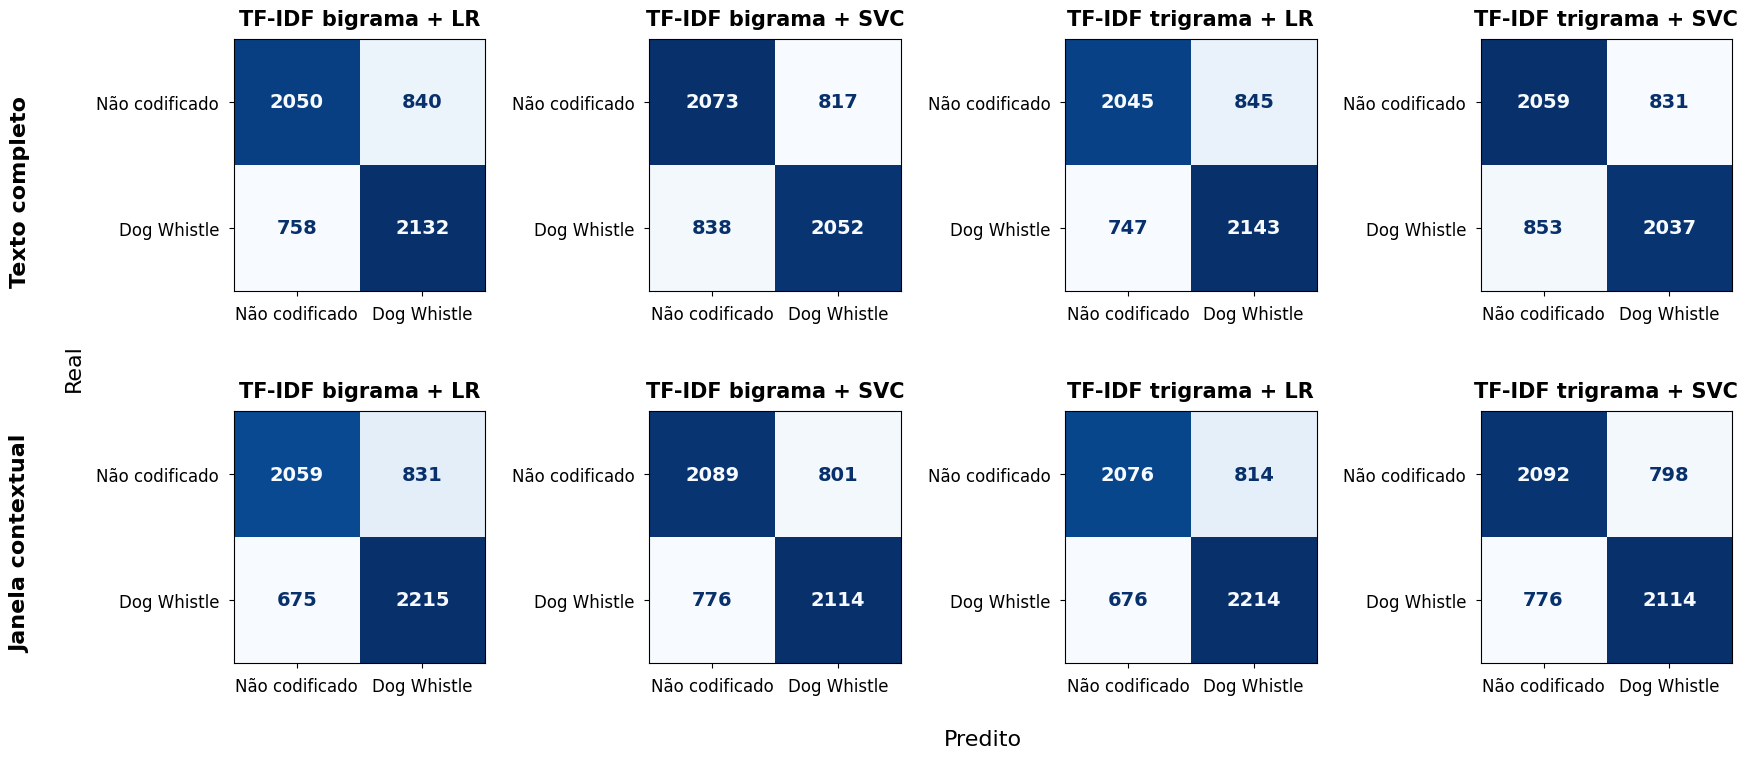

In [135]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


predictions_full = {
    "TF-IDF bigrama + LR": pred2_full,
    "TF-IDF bigrama + SVC": pred2_svc_full,
    "TF-IDF trigrama + LR": pred3_full,
    "TF-IDF trigrama + SVC": pred3_svc_full
}

predictions_context = {
    "TF-IDF bigrama + LR": pred2_context,
    "TF-IDF bigrama + SVC": pred2_svc_context,
    "TF-IDF trigrama + LR": pred3_context,
    "TF-IDF trigrama + SVC": pred3_svc_context
}


# =========================================================
# FIGURA
# =========================================================

fig, axes = plt.subplots(
    2, 4,
    figsize=(18, 8)
)


# =========================================================
# FUNÇÃO PARA PLOTAR CADA MATRIZ
# =========================================================

def plot_confusion_matrix(ax, y_true, pred, title):

    cm = confusion_matrix(
        y_true,
        pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Não codificado", "Dog Whistle"]
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
        cmap="Blues"
    )

    # -----------------------------------------------------
    # NÚMEROS DAS CÉLULAS
    # -----------------------------------------------------

    for text in disp.text_.ravel():
        text.set_fontsize(14)
        text.set_fontweight("bold")

    # -----------------------------------------------------
    # TÍTULO
    # -----------------------------------------------------

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=10
    )

    # -----------------------------------------------------
    # NÃO COLOCAR "REAL" E "PREDITO" EM CADA MATRIZ
    # -----------------------------------------------------

    ax.set_xlabel("")
    ax.set_ylabel("")

    # -----------------------------------------------------
    # RÓTULOS DAS CLASSES
    # -----------------------------------------------------

    ax.tick_params(
        axis="both",
        labelsize=12,
        pad=7
    )


# =========================================================
# TEXTO COMPLETO
# =========================================================

for j, (name, pred) in enumerate(predictions_full.items()):

    plot_confusion_matrix(
        axes[0, j],
        y2_test,
        pred,
        name
    )


# =========================================================
# JANELA CONTEXTUAL
# =========================================================

for j, (name, pred) in enumerate(predictions_context.items()):

    plot_confusion_matrix(
        axes[1, j],
        y2_test,
        pred,
        name
    )


# =========================================================
# IDENTIFICAÇÃO DAS LINHAS
# =========================================================

fig.text(
    0.025,
    0.72,
    "Texto completo",
    rotation=90,
    va="center",
    ha="center",
    fontsize=16,
    fontweight="bold"
)

fig.text(
    0.025,
    0.28,
    "Janela contextual",
    rotation=90,
    va="center",
    ha="center",
    fontsize=16,
    fontweight="bold"
)


# =========================================================
# EIXO Y — REAL
# ÚNICA VEZ E MAIS AFASTADO
# =========================================================

fig.text(
    0.055,
    0.50,
    "Real",
    rotation=90,
    va="center",
    ha="center",
    fontsize=16,
    fontweight="normal"
)


# =========================================================
# EIXO X — PREDITO
# ÚNICA VEZ E CENTRALIZADO
# =========================================================

fig.text(
    0.56,
    0.035,
    "Predito",
    va="center",
    ha="center",
    fontsize=16,
    fontweight="normal"
)


# =========================================================
# ESPAÇAMENTO
# =========================================================

plt.subplots_adjust(
    left=0.13,
    right=0.99,
    bottom=0.13,
    top=0.91,
    wspace=0.38,
    hspace=0.48
)


# =========================================================
# SALVAR
# =========================================================

plt.savefig(
    "matrizes_confusao_etapa2.png",
    dpi=350,
    bbox_inches="tight"
)

plt.show()

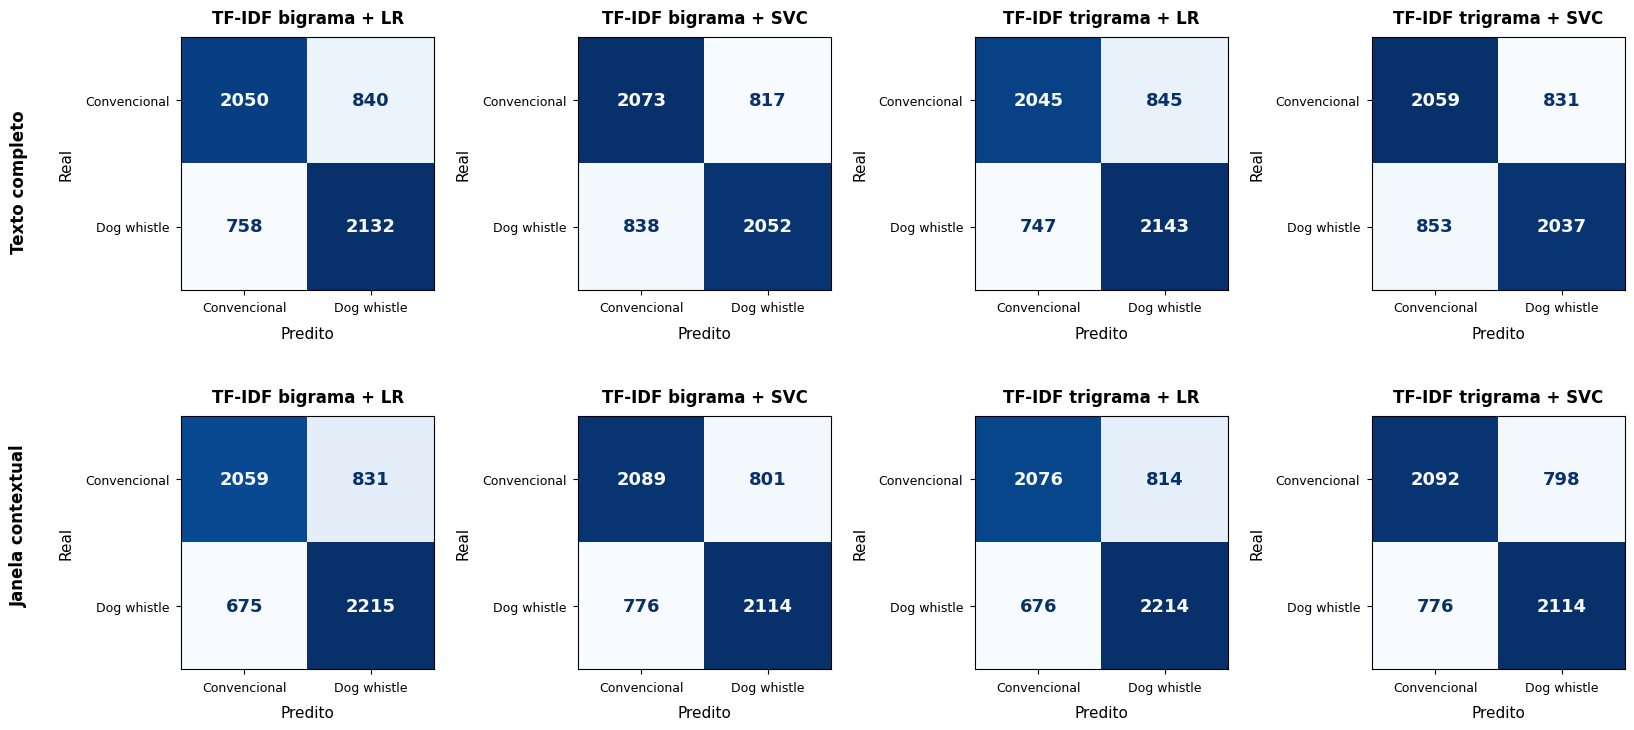

In [129]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions_full = {
    "TF-IDF bigrama + LR": pred2_full,
    "TF-IDF bigrama + SVC": pred2_svc_full,
    "TF-IDF trigrama + LR": pred3_full,
    "TF-IDF trigrama + SVC": pred3_svc_full
}

predictions_context = {
    "TF-IDF bigrama + LR": pred2_context,
    "TF-IDF bigrama + SVC": pred2_svc_context,
    "TF-IDF trigrama + LR": pred3_context,
    "TF-IDF trigrama + SVC": pred3_svc_context
}

fig, axes = plt.subplots(
    2, 4,
    figsize=(17, 8)
)

# Rótulos das classes
labels = ["Convencional", "Dog whistle"]


# =========================================================
# TEXTO COMPLETO
# =========================================================

for j, (name, pred) in enumerate(predictions_full.items()):

    ax = axes[0, j]

    cm = confusion_matrix(
        y2_test,
        pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
        cmap="Blues"
    )

    # Números dentro das células
    for text in disp.text_.ravel():
        text.set_fontsize(13)
        text.set_fontweight("bold")

    # Título
    ax.set_title(
        name,
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    # Eixos
    ax.set_xlabel(
        "Predito",
        fontsize=11,
        labelpad=8
    )

    ax.set_ylabel(
        "Real",
        fontsize=11,
        labelpad=8
    )

    # Tamanho dos rótulos
    ax.tick_params(
        axis="both",
        labelsize=9,
        pad=5
    )

    # Evita que os nomes das classes fiquem inclinados
    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        ha="center"
    )

    plt.setp(
        ax.get_yticklabels(),
        rotation=0,
        ha="right"
    )


# =========================================================
# JANELA CONTEXTUAL
# =========================================================

for j, (name, pred) in enumerate(predictions_context.items()):

    ax = axes[1, j]

    cm = confusion_matrix(
        y2_test,
        pred,
        labels=[0, 1]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=labels
    )

    disp.plot(
        ax=ax,
        values_format="d",
        colorbar=False,
        cmap="Blues"
    )

    # Números dentro das células
    for text in disp.text_.ravel():
        text.set_fontsize(13)
        text.set_fontweight("bold")

    # Título
    ax.set_title(
        name,
        fontsize=12,
        fontweight="bold",
        pad=10
    )

    # Eixos
    ax.set_xlabel(
        "Predito",
        fontsize=11,
        labelpad=8
    )

    ax.set_ylabel(
        "Real",
        fontsize=11,
        labelpad=8
    )

    # Tamanho dos rótulos
    ax.tick_params(
        axis="both",
        labelsize=9,
        pad=5
    )

    # Evita sobreposição
    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        ha="center"
    )

    plt.setp(
        ax.get_yticklabels(),
        rotation=0,
        ha="right"
    )


# =========================================================
# IDENTIFICAÇÃO DAS LINHAS
# =========================================================

fig.text(
    0.02, 0.72,
    "Texto completo",
    rotation=90,
    va="center",
    ha="center",
    fontsize=12,
    fontweight="bold"
)

fig.text(
    0.02, 0.29,
    "Janela contextual",
    rotation=90,
    va="center",
    ha="center",
    fontsize=12,
    fontweight="bold"
)


# =========================================================
# AJUSTES FINAIS
# =========================================================

plt.subplots_adjust(
    left=0.10,
    right=0.98,
    bottom=0.11,
    top=0.90,
    wspace=0.30,
    hspace=0.50
)

plt.savefig(
    "matrizes_confusao_etapa2_nova.png",
    dpi=350,
    bbox_inches="tight"
)

plt.show()

### Word2Vec

In [84]:
df_etapa2 = df_etapa2.copy()

df_etapa2["tokens"] = df_etapa2["content"].map(tokenize)

train2_tokens = df_etapa2.loc[X2_train.index, "tokens"]
test2_tokens = df_etapa2.loc[X2_test.index, "tokens"]

In [85]:
w2v = Word2Vec(
    sentences=train2_tokens,
    vector_size=200,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    negative=10,
    epochs=20,
    seed=RANDOM_STATE
)

In [86]:
palavras = w2v.wv.index_to_key[:10]

df_vectors = pd.DataFrame(
    [w2v.wv[p] for p in palavras],
    index=palavras
)

display(df_vectors)

,0,1,2,3,4,5,6,7,8,9,...,190,191,192,193,194,195,196,197,198,199
the,-0.045107,0.115254,-0.008446,0.037066,0.003966,0.228083,-0.202444,0.222605,-0.225752,0.050541,...,-0.093453,0.054305,-0.116562,-0.207954,0.044271,-0.233470,-0.015859,0.126607,0.082291,-0.052791
to,0.073808,0.051135,0.045500,0.049293,-0.090353,-0.005065,0.098119,0.230024,-0.267197,0.002841,...,-0.242650,-0.008862,-0.179000,-0.263619,0.001687,-0.395326,-0.139209,0.071483,0.069567,-0.052223
and,-0.000753,0.035651,-0.164360,-0.041089,-0.105485,-0.054131,-0.016357,0.060696,-0.069144,0.118992,...,-0.063530,0.082618,0.077946,-0.158948,0.085184,-0.259121,0.024027,0.259308,-0.010935,-0.123402
a,0.227183,-0.017476,-0.098122,0.077630,0.093357,-0.095156,-0.188661,-0.028987,0.140146,-0.042928,...,-0.054325,-0.035331,0.152671,0.025302,0.141332,-0.503690,0.097374,0.369540,0.028206,0.082283
of,-0.307715,0.135850,-0.222172,0.015814,-0.088782,-0.001951,-0.010055,-0.037830,-0.116937,0.076749,...,-0.269572,-0.039329,-0.072184,-0.071546,-0.017685,-0.155292,0.102148,0.347162,0.321994,-0.189489
is,0.351299,0.142519,-0.000880,0.077048,-0.171728,0.300058,0.017714,-0.040180,-0.114440,-0.012184,...,-0.019519,-0.049733,0.001859,-0.113233,-0.117673,-0.123144,0.065792,0.107369,0.048837,0.105209
that,0.286573,-0.112779,0.080768,0.144294,-0.249082,-0.089328,-0.026398,0.147858,-0.255248,-0.041958,...,-0.013812,-0.013119,0.057620,-0.224562,-0.178139,-0.203574,0.109910,0.123084,-0.150232,-0.002151
in,0.119126,0.300381,-0.216372,-0.103889,0.041702,-0.112302,-0.017798,-0.132856,-0.321017,0.062796,...,-0.200908,-0.045314,-0.093617,-0.265586,0.125297,-0.308365,0.037284,0.268563,-0.040630,0.100288
i,0.264565,0.077073,0.116636,0.005838,-0.090895,0.070126,-0.286381,0.149078,-0.094925,-0.054512,...,-0.069957,0.279333,-0.027772,-0.056903,-0.241466,-0.386919,0.178198,0.091225,-0.151995,-0.022052
for,-0.029502,0.318504,0.070102,0.011649,0.018510,-0.223890,0.043078,-0.165568,-0.146783,0.010168,...,-0.074661,0.088125,-0.073258,-0.083765,-0.136185,-0.414881,0.185634,0.177579,-0.091924,-0.236942


In [87]:
print("Tamanho do vocabulário:", len(w2v.wv))
print("Dimensão dos vetores:", w2v.vector_size)

Tamanho do vocabulário: 13991
Dimensão dos vetores: 200


### Testando classificação

In [88]:
def document_vector(tokens, model):
    vectors = [
        model.wv[token]
        for token in tokens
        if token in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [89]:
X2_train_w2v = np.array([
    document_vector(tokens, w2v)
    for tokens in train2_tokens
])

X2_test_w2v = np.array([
    document_vector(tokens, w2v)
    for tokens in test2_tokens
])

In [90]:
X2_train_w2v[0]

array([ 1.21481560e-01,  4.50047851e-02, -7.07662106e-03, -1.40495077e-01,
       -4.93041873e-02, -8.81020054e-02,  5.93996905e-02,  2.63762861e-01,
       -1.70665696e-01, -1.03307322e-01, -7.98567161e-02, -9.47563425e-02,
        1.29441479e-02,  9.33034942e-02, -9.02468152e-03, -1.56890988e-01,
        1.39802784e-01,  1.19528554e-01,  1.06455915e-01, -1.16674021e-01,
        2.16130584e-01,  1.89156845e-01, -1.64444461e-01,  1.86633263e-02,
        1.76297158e-01,  2.12769300e-01, -1.42433107e-01,  1.73000187e-01,
       -2.59423424e-02, -2.80604064e-02, -4.13975911e-03, -1.43145397e-01,
       -1.46670774e-01, -2.40758568e-01, -8.69323015e-02, -3.89338695e-02,
        3.33489090e-01, -1.32446989e-01, -4.11767960e-02,  2.85682350e-01,
        5.51085062e-02,  8.82352591e-02,  7.08777159e-02,  1.80515319e-01,
       -4.24962044e-02, -8.30274448e-02, -1.12019695e-01,  2.49933582e-02,
        3.18227440e-01, -6.15059137e-02, -4.24866863e-02,  3.30751017e-02,
        2.88664788e-01, -

In [91]:
model2_w2v = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE
)

model2_w2v.fit(
    X2_train_w2v,
    y2_train
)

pred2_w2v = model2_w2v.predict(
    X2_test_w2v
)

In [92]:
print(classification_report(y2_test, pred2_w2v))

              precision    recall  f1-score   support

           0       0.66      0.65      0.65      2890
           1       0.65      0.66      0.66      2890

    accuracy                           0.65      5780
   macro avg       0.65      0.65      0.65      5780
weighted avg       0.65      0.65      0.65      5780



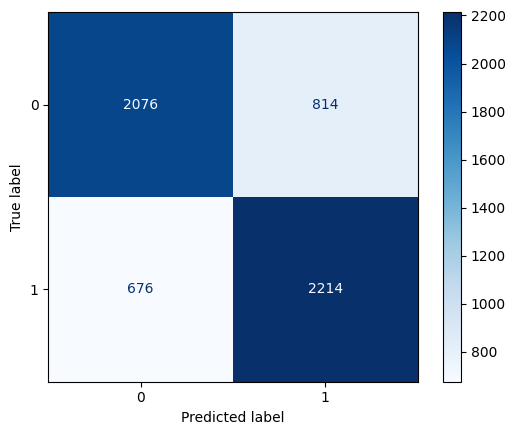

In [93]:
cm2 = confusion_matrix(y2_test, pred2_w2v)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.show()

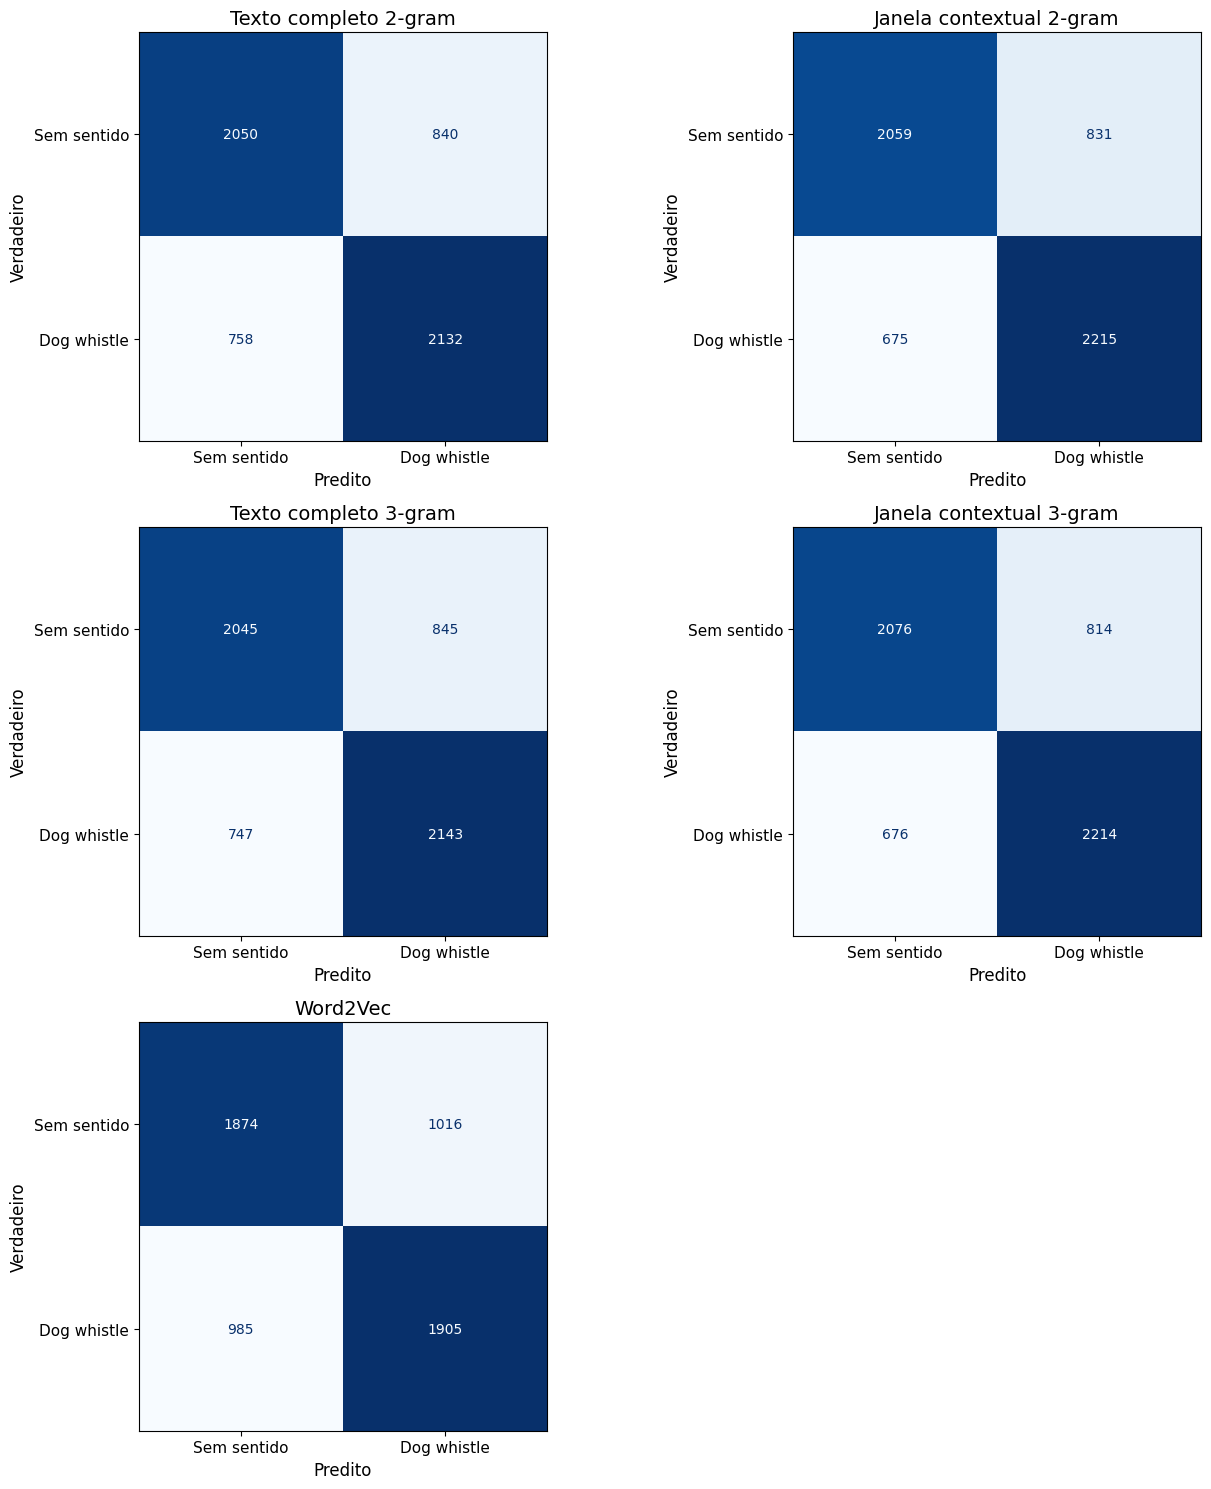

In [148]:
plots_data = [
    ("Texto completo 2-gram", y2_test, pred2_full),
    ("Janela contextual 2-gram", y2c_test, pred2_context),
    ("Texto completo 3-gram", y2_test, pred3_full),
    ("Janela contextual 3-gram", y3c_test, pred3_context),
    ("Word2Vec", y2_test, pred2_w2v)  # <- cm2 incluído aqui
]

# Criar grid de subplots (ajuste linhas/colunas conforme necessário)
fig, axes = plt.subplots(3, 2, figsize=(14, 15))  # 3 linhas, 2 colunas
axes = axes.flatten()

# Plotar todas as matrizes
for ax, (name, y_true, y_pred) in zip(axes, plots_data):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Sem sentido", "Dog whistle"]
    )
    disp.plot(ax=ax, values_format="d", colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=14)
    ax.set_xlabel("Predito", fontsize=12)
    ax.set_ylabel("Verdadeiro", fontsize=12)
    ax.set_xticklabels(["Sem sentido", "Dog whistle"], fontsize=11)
    ax.set_yticklabels(["Sem sentido", "Dog whistle"], fontsize=11)

axes.ravel()[-1].remove()

# Ajustar layout
plt.tight_layout()
plt.savefig("09_matrizes_confusao_etapa2.png", dpi=350, bbox_inches="tight")
plt.show()

In [94]:
w2v_result = binary_metrics(
    y2_test,
    pred2_w2v,
    "Word2Vec (SGNS) + Logistic Regression"
)

stage2_results = pd.concat(
    [
        stage2_results,
        pd.DataFrame([w2v_result])
    ],
    ignore_index=True
)

display(stage2_results.round(4))

,modelo,accuracy,precision,recall,f1,balanced_accuracy
0,TF-IDF 2-gram texto completo + LR,0.7235,0.7174,0.7377,0.7274,0.7235
1,TF-IDF 3-gram texto completo + LR,0.7246,0.7172,0.7415,0.7292,0.7246
2,TF-IDF 2-gram janela contextual + LR,0.7394,0.7272,0.7664,0.7463,0.7394
3,TF-IDF 3-gram janela contextual + LR,0.7422,0.7312,0.7661,0.7482,0.7422
4,Word2Vec (SGNS) + Logistic Regression,0.6538,0.6522,0.6592,0.6557,0.6538


In [95]:
resultado_w2v = pd.DataFrame({
    "texto": X2_test.values,
    "real": y2_test.values,
    "predito": model2_w2v.predict(X2_test_w2v)
}, index=y2_test.index)

In [96]:
probs = model2_w2v.predict_proba(X2_test_w2v)

resultado_w2v["prob_0"] = probs[:, 0]
resultado_w2v["prob_1"] = probs[:, 1]

resultado_w2v["confianca"] = probs.max(axis=1)

In [97]:
erros = resultado_w2v[resultado_w2v["real"] != resultado_w2v["predito"]]

erros.sort_values("confianca", ascending=False).head(30)

,texto,real,predito,prob_0,prob_1,confianca
18321,"No, he is just another virtue signaling Hollyw...",0,1,0.027052,0.972948,0.972948
28303,[Some interesting stats about Chicago here.]( ...,1,0,0.963866,0.036134,0.963866
13864,Lawabiding citizens and victims of crime stood...,0,1,0.037297,0.962703,0.962703
27905,Exactly. Fuck the shills and concern trolls! F...,0,1,0.054431,0.945569,0.945569
6707,If you can't get her on the train at least get...,1,0,0.934137,0.065863,0.934137
15101,Israel needs to be true to its Jewish values a...,0,1,0.069856,0.930144,0.930144
7877,You should check out the early life section of...,1,0,0.929182,0.070818,0.929182
17210,I'm buying a copy of this book and gifting it ...,1,0,0.926701,0.073299,0.926701
4310,We are doing what they want. reining in govern...,0,1,0.077172,0.922828,0.922828
5992,It is incumbent on every pede to apply for a C...,1,0,0.914744,0.085256,0.914744


### Analisando a similaridade identificada entre os termos pelo W2V

In [98]:
termo = "globalists"

if termo in w2v.wv:
    display(pd.DataFrame(w2v.wv.most_similar(termo, topn=20), columns=["palavra", "similaridade"]))

,palavra,similaridade
0,oligarchs,0.498723
1,deepstate,0.498251
2,propagandists,0.496316
3,shoutout,0.493584
4,architects,0.491794
5,satanism,0.484725
6,transnational,0.480832
7,warmongers,0.480158
8,puppets,0.477331
9,swedistan,0.470345


### Testando contexto local

In [99]:
def local_context(tokens, term, window=5):
    term = term.lower()

    if term not in tokens:
        return []

    pos = tokens.index(term)

    start = max(0, pos - window)
    end = min(len(tokens), pos + window + 1)

    context = tokens[start:pos] + tokens[pos + 1:end]

    return context

In [100]:
idx = X2_train.index[0]

tokens = df_etapa2.loc[idx, "tokens"]
term = df_etapa2.loc[idx, "dog_whistle"]

print("Termo:")
print(term)

print("Texto tokenizado:")
print(tokens)

print("Contexto local:")
print(local_context(tokens, term, window=5))

Termo:
globalists
Texto tokenizado:
['meanwhile', 'these', 'neoconservative', 'globalists', 'sent', 'jobs', 'to', 'communist', 'china', 'these', 'people', 'are', 'communists', 'dipshit']
Contexto local:
['meanwhile', 'these', 'neoconservative', 'sent', 'jobs', 'to', 'communist', 'china']


In [101]:
def local_context_vector(tokens, term, model, window=5):
    
    context = local_context(
        tokens,
        term,
        window=window
    )

    vectors = [
        model.wv[token]
        for token in context
        if token in model.wv
    ]

    if len(vectors) == 0:
        return np.zeros(model.vector_size)

    return np.mean(vectors, axis=0)

In [102]:
X2_train_w2v_local = np.array([
    local_context_vector(
        df_etapa2.loc[idx, "tokens"],
        df_etapa2.loc[idx, "dog_whistle"],
        w2v,
        window=5
    )
    for idx in X2_train.index
])

X2_test_w2v_local = np.array([
    local_context_vector(
        df_etapa2.loc[idx, "tokens"],
        df_etapa2.loc[idx, "dog_whistle"],
        w2v,
        window=5
    )
    for idx in X2_test.index
])

In [103]:
model2_w2v_local = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=RANDOM_STATE
)

model2_w2v_local.fit(
    X2_train_w2v_local,
    y2_train
)

pred2_w2v_local = model2_w2v_local.predict(
    X2_test_w2v_local
)

In [104]:
print(classification_report(y2_test, pred2_w2v_local))

              precision    recall  f1-score   support

           0       0.66      0.51      0.57      2890
           1       0.60      0.73      0.66      2890

    accuracy                           0.62      5780
   macro avg       0.63      0.62      0.62      5780
weighted avg       0.63      0.62      0.62      5780



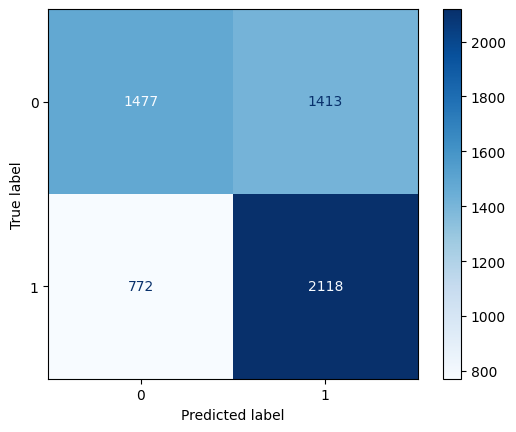

In [105]:
cm_local = confusion_matrix(
    y2_test,
    pred2_w2v_local
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_local
)

disp.plot(cmap="Blues")


plt.show()

### Treinando a IlumA

In [106]:
BASE_URL = "https://iluma.cnpem.br:4000/v1"
MODELO = "iluma"          # o único modelo publicado no gateway

# O manual de qualquer API diz "para extração, use temperature=0". Aqui não dá:
# o modelo por trás da IlumA é um Qwen e, nesta instalação, valores abaixo de
# ~0,5 fazem a chamada TRAVAR — ela simplesmente não retorna. 0,5 é o mais
# determinístico que conseguimos.
TEMP_EXTRACAO = 0.5

# getpass não ecoa o que você digita e não guarda nada no notebook salvo.
token = getpass.getpass("cologa a chavi")

# timeout explícito: sem ele, uma chamada que trava fica pendurada para sempre e
# só sai com Ctrl-C. Melhor falhar em 60 s e saber que falhou.
cliente = OpenAI(base_url=BASE_URL, api_key=token, timeout=600.0, max_retries=1)

cologa a chavi ········


In [107]:
# Teste de conexão — se isto responder, está tudo certo.
resposta = cliente.chat.completions.create(
    model=MODELO,
    messages=[{"role": "user", "content": "Responda apenas: conexão OK."}],
)
print(resposta.choices[0].message.content)



conexão OK.


In [108]:
amostra_df = df_geral.sample(35, random_state= 42)

In [111]:
def perguntar(pergunta, sistema=None, max_tokens=16000, temperature=0.8, json_mode=False):
    """Devolve (conteudo, raciocinio, finish_reason).

    `conteudo` vem None quando o max_tokens acaba durante o raciocinio — ele
    consome o mesmo orcamento. Nesse caso finish_reason e 'length'.

    Use json_mode=True quando esperar JSON. Sem isso, prompt vago faz o modelo
    divagar: medido em 24/09/2026 na mesma pergunta, sem json_mode gastou os
    16000 tokens so raciocinando e devolveu None; com json_mode, 1605 tokens
    e resposta correta.
    """
    mensagens = []
    if sistema:
        mensagens.append({"role": "system", "content": sistema})
    mensagens.append({"role": "user", "content": pergunta})

    extra = {"response_format": {"type": "json_object"}} if json_mode else {}

    r = cliente.chat.completions.create(
        model="iluma",
        messages=mensagens,
        max_tokens=max_tokens,
        temperature=temperature,
        **extra,
    )
    msg = r.choices[0].message
    # getattr: 'reasoning' nao e campo padrao da OpenAI.
    return msg.content, getattr(msg, "reasoning", None), r.choices[0].finish_reason


if __name__ == "__main__":
    SISTEMA = '''Um apito de cachorro é uma forma de linguagem codificada que engloba termos que, para o público geral, possuem significado comum, mas para um grupo específico, serve como um código para se comunicar com grupos específicos. Termos desse tipo normalmente estão associados a linguagem de ódio e palavras ofensivas. Essa é uma lista de alguns termos que são associados a apito de cachorro: 

    'institution of marriage' 'cuckolds' 'SJW' 'special interest' 'cabal'
 'working families' 'male socialization' 'centipede' 'based' 'Google'
 'single mom' 'terrorism' 'beta' 'single' 'cuck' 'affirmative action'
 'middle class' 'diversity quotas' 'inner cities'
 'social justice warriors' 'terrorist' 'single parent' 'trans activist'
 'dindus' 'Kek' 'MAGA' 'pedes' 'biological woman' 'bix nood' 'beta male'
 'Pajeets' 'Chicago' 'multiCULTi' 'safeguard' 'oy vey' 'Baltimore' 'pede'
 'coincidence' 'absent father' 'illegal immigrant' 'the Fed'
 'entitlement program' 'single mother' 'racial realism' 'Pepe'
 'hardworking Americans' 'race realism' 'Islamists' 'terrorists'
 'genderist' "Let's Go Brandon" 'welfare' 'tax cut' 'alt-right'
 'school vouchers' 'job creation' 'New York intellectuals' 'TRA'
 'snowflake' 'securing our border' 'dual loyalty' 'Hollywood' 'baby mama'
 'religious liberty' 'neolibs' 'agender' 'fraudulent voting' 'CRT'
 'public schools' 'biological sex is real' 'gender crit' 'entitlement'
 'globalists' 'ghetto' 'Soros' 'cucks' 'identify as'
 'traditional marriage' 'superpredators' 'quotas' 'balance the budget'
 'alarmists' 'TIM' 'Skype' 'TRAs' 'globalist' 'Illuminati' 'magapedes'
 'SJWs' 'neoliberal' 'healthy tissue' 'end birthright citizenship'
 'entitlements' 'shoah' 'freedom to work' 'handouts' 'autogynephiles'
 'illegal immigrants' 'zog' 'cuckservatives' 'grooming'
 'judicial activism' 'school choice' 'goy' 'cosmopolitans' 'working class'
 'echo' 'criminal alien' 'coal burner' 'soy' 'LGB' 'illegal alien'
 'radical Islam' 'public school' 'urban' 'right to know' 'big government'
 'multicultural' 'HH' 'blue' 'male violence' 'war on drugs' 'boogaloo'
 'troon' 'COIN' 'economic freedom' 'rootless cosmopolitan' 'law and order'
 'Rothschilds' 'mud sharks' 'tax cuts' 'illegals' 'Shariah'
 'mass immigration' 'Amerimutt' 'Islamic terrorism' 'cultural enrichment'
 'snowflakes' 'cultural Marxism' 'Jwoke' 'biological male' 'Carolus Rex'
 'handout' 'multiculturalism' 'anchor baby' '13/50' 'religious liberties'
 'thugs' 'biological women' 'Skittles' 'climate alarmists'
 'helicopter rides' 'extremists' 'international banks' 'Remove Kebab'
 'voter fraud' 'quota' 'central bankers' 'food stamp'
 'open borders for Israel' 'soybois' 'silent majority' 'sex not gender'
 'personal responsibility' 'Trans Identified Male' 'Honkler'
 'take our country back' 'as a white person' 'GC'
 'black-on-black violence' 'bankers' "shoah'd" 'rootless cosmopolitans'
 'dual citizen' 'religious freedom' 'deep state' 'EST' 'gangbanger'
 'car salesmen' 'health freedom' '#BlueLivesMatter' 'lack of fathers'
 'steroids' 'war on terror' 'Clown World' 'family values'
 'judicial activists' 'butterfly' 'merit-based immigration' 'broken home'
 'gibs' 'identitarian' 'activist judge' 'inner city' 'RaHoWa'
 'right-to-work laws' 'shoahed' 'food stamps' 'biological reality'
 'intact male' 'actual woman' 'Khazar' 'our guy' 'Shlomo' 'welfare reform'
 'criminal aliens' 'erasure of women' 'limp-wristed' 'gender ideology'
 'Kalergi Plan' 'criminal illegal alien' 'gibsmedat' 'NPCs'
 'controlled media' 'gender abolition' 'three strikes'
 'balancing the budget' 'job creator' 'power level' 'activist judges'
 'international banker' 'extremist' 'cosmopolitan elite' 'ghettos'
 'climate alarmist' 'Wuhan Virus' 'trans rights activist' 'baby daddies'
 'uterus-havers' 'adult human females' 'Zionist' 'Cohencidences'
 'burn the coal' 'AGPs' 'anointing' 'Barack Hussein' 'neoliberals'
 'secure our border' 'forced busing' 'three strikes law'
 'government spending' 'Islamist' 'Sharia law' 'you know who' 'Reagan'
 'All Lives Matter' 'biological males' 'multi-kulti' '13%' 'Drop the T'
 'XX' 'YKW' 'Deus Vult' 'alarmist' 'coal burners' 'LGB rights'
 'individual responsibility' 'forced diversity' 'frens' 'education reform'
 '30 pieces of silver' 'kebab removal' 'cuckservative' 'illegal aliens'
 'Israel Lobby' 'Zio' 'shut it down' 'string pullers' 'jogger'
 'Make America Great Again' 'string puller' 'baby mommas' 'young buck'
 'womxn' 'welfare cheats' 'take back' 'America First' 'gangbangers'
 'troons' 'fatherless' 'gender fandom' 'Sharia' 'job creators'
 'government handout' 'coastal elites' 'nimble navigators'
 'biological females' 'Detroit' '41' 'fatherless children' 'TIMs' '14/88'
 'climate alarmism' 'middle class Americans' 'three strikes policy'
 'broken homes' "it's okay to be white" 'joggers' 'womyn' 'gang banger'
 'social justice warrior' 'banking cabal' 'centipedes' 'cultural Marxist'
 '#AmericaFirst' 'secure the border' 'Volodymyr Zelensky'
 'he was a good boy' 'politically correct' 'cut taxes' 'abolish gender'
 'puppet masters' 'single-parent household' 'political correctness' 'TIF'
 'soyboi' 'sex-based rights' 'send me' 'autogynophiles' '1488' 'NPC'
 'natal women' 'disloyalty' 'baby mamas' 'international elite'
 'property rights' 'medical freedom' 'we wuz kangs' 'bugman'
 'adult human female' 'groomers' "states' rights" 'Black Sun' 'intact'
 'nimble navigator' 'Khazars' 'Bernie Sanders' 'vaccine safety'
 'actual women' 'out of wedlock' '((()))' "protect women's sports"
 'socialized as female' 'inner-city' 'critical race theory'
 'dual citizenship' 'biological men' 'Feels Good Man' 'OK sign'
 'deadbeats' 'neoliberalism' 'Cleveland' 'big pharma' 'alternative right'
 'Googles' 'cuckold' 'protect women and girls' 'black on black crime'
 'gender identity ideology' 'deadbeat dad' 'Hussein Obama'
 'male socialisation' 'thug' 'AGP' 'fellow whites' 'cosmopolitan'
 'shekels' 'New World Order' 'entitlement spending' 'war on terrorism'
 'big igloo' 'removing kebab' 'dual citizens' 'groomer' 'erasing women'
 'lesbian erasure' 'global elites' 'clownfish' 'RWDS' 'surgical wounds'
 'Zionists' 'Pajeet' 'goyim' 'soy boy' 'buck' 'Wojak' 'bankster'
 'La Creatura' 'identitarianism' 'neolib' 'Hollywood liberals' 'banker'
 'traditional family values' 'string-pullers' 'freedom of association'
 '88' 'majority-minority' 'banksters' 'Three Percenters'
 'human biodiversity' 'black-on-black crime' 'burn coal' 'right to work'
 'working class communities' 'New York values' 'freedom of religion'
 'hygienic' 'black on black violence' "it's ok to be white" 'mud shark'
 'YWNBAW' 'fren world' 'global cabal' 'radical Islamist' 'global elite'
 'colorblindness' 'Dred Scott' 'entitlement programs' 'dual loyalties'
 'preemptive strike' 'Zios' 'Reagans' 'natal men' 'Schlomo'
 'gender abolitionist' 'coastal elite' 'puppet master' 'womanface'
 'dindu nuffin' 'brave and stunning' 'NWO' 'ALM' 'Kung Flu' 'shekel'
 'Islamic terrorist' 'erasing lesbians' 'safeguarding' 'autogynephile'
 'gib me dat' 'pre-emptive strike' 'Skypes' 'JQ' 'Judeo-Christian'
 'China Virus' 'mass migration' 'the goyim know' 'never married'
 'trans-identified female' 'extremism' 'Amish' 'implicit bias'
 'racial quotas' 'government handouts' 'special interests' 'deadbeat'
 'AFAB trans woman' 'pulling the strings' '56%' '13/52'
 'radical gender ideology' 'color-blind society' 'thin blue line'
 'mixed-sex' 'welfare queens' '/our guy/' 'biological man' '14 words'
 'forced bussing' 'butterflies' 'welfare queen' 'burns coal'
 'judicial activist' 'thin blue line flag' 'TIFs' 'SWPL'
 'Islamic extremist' 'hard-working American' 'Shariah law' 'anti-grooming'
 'uterus haver' 'fren' '#itsokaytobewhite' 'majority minority'
 'hardworking American' 'election integrity' 'Trilateral Commission'
 'White Lives Matter' 'educational choice' 'nibbas' 'fatherless home'
 'tough on crime' 'AAP' 'A Leppo' '109' 'colorblind'
 'thirty pieces of silver' 'super predators' 'blueish'
 'female socialisation' 'SPQR' 'autogynophilia' 'windmill' 'ZOG' '1290'
 'pro-family' 'super predator' 'George Soros' 'broken families'
 'we wuz kangz' '#itsoktobewhite' 'Trans Identified Males'
 'female socialization' 'sex is real' 'confirmed bachelor'
 'pull the strings' 'coincidences' 'race realist' 'gang bangers'
 'black on black homicide' 'globalism' 'burned coal' 'fatherless child'
 'absentee father' 'alarmism' 'cutting taxes' 'milk emoji'
 'black-on-black homicide' 'male-friendly' 'overpopulation' 'natal woman'
 'radical Islamists' 'octopus' 'Skittle' 'Bing' 'take back our country'
 'Vinland' 'Judas' 'Blue Lives Matter' 'biological realism' 'ghettoes'
 'soy boys' 'scientific racism' 'Trans Identified Female' 'media control'
 'war on Christmas' 'Super Straight' 'Judeo-Christian values'
 'Cohencidence' 'biological realist' '#alllivesmatter' 'triple brackets'
 'lifelong bachelor' 'vegan cat' 'Sunwheel' 'triple parentheses'
 'fatherless homes' 'broken family' '3%ers' 'Rothschild' 'we wuz kings'
 'Durden' 'COINing' 'protecting women and girls' '(((fellow whites)))'
 'working-class' 'race realists' 'genderists' 'dindu' 'baby momma'
 'anointed' 'pilpul' 'HBD' 'merit-based immigration policy'
 'clean up our streets' 'middle-class Americans' 'WLM'
 'working class families' 'physical removal' 'genderfree'
 'the welfare queen' 'superstraight' 'autogynophile' 'autogynephilia'
 'genderless' 'identitarians' 'trans rights activists' 'Lloyd Blankfein'
 'bugmen' 'Trans Identified Females' 'anchor babies' 'dissident right'
 'Islamic extremists' 'Hollywood moguls' 'Islamic extremism' '110'
 'economic anxiety' 'loxism' '(((echo)))' 'surgical wound' 'war on crime'
 'superpredator' 'magapede' 'rigged election' 'socialized as male'
 'trans-identified male' 'Willie Horton' 'Judeo-Christianity' 'Yahoo'
 'Holocauster' 'early life section' 'parental choice' 'voting fraud'
 "don't see color" '41%' 'working-class communities' 'gender woo woo'
 'big luau' 'bop' 'central banker' 'tiny minority of men' 'Kekistan'
 'Rothschild family' 'FAFO' 'car salesman' 'baby daddy' 'bops'
 'windmill of friendship' 'Charles XII' 'safeguarding children'
 'Dred Scott decision' 'co-opting intersex narratives' 'vagina haver'
 'Goody' 'da goyim know' 'Janet Yellen' 'superlesbian'
 'securing the border' 'Manhattan elite' 'New York elite'
 'fellow white people' 'Wojaks' 'gender-critical feminism'
 'Hollywood elite' 'poisoning the well' 'Sonnenrad' 'nibba'
 'shadowy cabal' 'early life' 'overpopulating the planet'
 'has no children' 'welfare cheat' 'bopped' 'international bankers'
 'lesbophobia' 'trans-rights activist' 'Yahoos' 'gender socialization'
 'radical Islamic terrorists' 'Zionist Occupation Government'
 'autoandrophilia' 'implicit biases' 'bear emoji' 'bluish'
 'gender abolitionists' "protecting women's spaces" 'Federal Reserve'
 'child safeguarding' 'III%ers' 'pulling strings' 'Hollywood elites'
 'protecting property rights' 'Back the Blue' 'burning coal' 'boogalo'
 'deadbeat dads' 'Pepe the Frog' 'socialised as male' 'intact man' 'Aiden'
 'elitist cabal' 'radical Islamic terrorism' 'biological female'
 'never-married' 'local control of schools' 'Islamic terrorists'
 'nose check' 'gender socialisation' 'Karl XII' 'Serbia Strong'
 'global special interests' 'the Hawaiian shirt'
 'points-based immigration' 'hard-working Americans' 'God-given liberties'
 'intact female' 'mixed sex']

Esse é um exemplo de frase que não está usando nenhum termo associado a um apito de cachorro:

"Well, I'm no cook, but can't you just quickly Google a recipe from a legitimate-looking site? That's definitely what I would do. Sorry about not actually providing you with a recipe though, I don't know how to bake either :S"

Esse é um exemplo de frase que possuí um termo associado a apito de cachorro, mas que encontra-se em um contexto de uso comum:

"Designing, manufacturing, installing, and maintaining infrastructure that will replace the current fossil fuel based energy infrastructure."

Esse é um exemplo de frase que possuí um termo associado a apito de cachorro dentro de um contexto onde a linguagem codificada é intencional: 

"Ughhh.... it's like a cucked low energy knock off of /r/the_donald Proof that market based meme economies produce top quality product."

A partir disso classifique as seguintes frases como não possuindo nenhum termo associado a apito de cachorro indicado pelo número 2, possuindo termo associado a apito de cachorro mas com o sentido normal da palavra indicado pelo número 0, como possuindo termo associado a apito mas com o sentido codificado pelo número 1.
'''
    for i, (_, linha) in enumerate(amostra_df.iterrows(), 1):

        sentenca = linha["content"]
        rotulo_correto = str(linha["label"])
        
        conteudo, raciocinio, motivo = perguntar(sentenca, sistema=SISTEMA, json_mode=True)

        with open(f"item_{i}.json", "w", encoding="utf-8") as f:
            json.dump({
                "input": sentenca,
                "expected": rotulo_correto,
                "output": conteudo,
                "reasoning": raciocinio,
                "finish_reason": motivo,
            }, f, ensure_ascii=False, indent=2)

        if conteudo is None:
            print(f"[{i}] sem resposta: o raciocinio consumiu todo o max_tokens")
        else:
            print(f"[{i}] ok ({motivo}) -> item_{i}.json")

[1] ok (stop) -> item_1.json
[2] ok (stop) -> item_2.json
[18] ok (stop) -> item_18.json
[19] ok (stop) -> item_19.json
[20] ok (stop) -> item_20.json
[21] ok (stop) -> item_21.json
[22] ok (stop) -> item_22.json
[23] ok (stop) -> item_23.json
[24] ok (stop) -> item_24.json
[25] ok (stop) -> item_25.json
[26] ok (stop) -> item_26.json
[27] ok (stop) -> item_27.json
[29] ok (stop) -> item_29.json
[30] ok (stop) -> item_30.json
[31] ok (stop) -> item_31.json
[32] ok (stop) -> item_32.json
[33] ok (stop) -> item_33.json
[34] ok (stop) -> item_34.json
[35] ok (stop) -> item_35.json


In [ ]:
import glob

arquivos = glob.glob("item_*.json")

for arquivo in arquivos:
    
    with open(arquivo, "r", encoding="utf-8") as f:
    
        resultado = json.load(f)

print("=" * 50)
print("Arquivo:", arquivo)
print("Entrada:", resultado["input"])
print("Resposta:", resultado["output"])

Arquivo: item_9.json
Entrada: My hometown (Murrieta) was the place that forced the Highway Patrol busses full of illegal immigrant kids to turn around and go back to Texas though, so I imagine that mentality will align with voting for Trump.
Resposta: {
  "classification": 1,
  "reasoning": "The sentence contains the term 'illegal immigrant', which is present in the provided list of dog whistle terms. The context of the sentence (referencing the Murrieta border protest, turning back buses, and aligning with voting for Trump) signals an ideological alignment with the specific rhetoric associated with these terms (anti-immigration, border security, right-wing populism). The usage is not merely descriptive but functions as a signal of in-group political stance, fitting the definition of coded usage (1) rather than neutral/common usage (0) or absence of terms (2)."
}


In [ ]:
import json

with open("item_1.json", "r", encoding="utf-8") as f:
    resultado = json.load(f)

resultado

{'input': 'a basic banjo is not expensive.  Try out a Deering Goodtime II great sound and you can get them for around $300-$400 dollars and they sound great.  Why the heck would you buy a guitar if you want to play the banjo?',
 'expected': '2',
 'output': '{\n  "classification": 2,\n  "reason": "A frase não contém nenhum dos termos da lista fornecida associada a \'apito de cachorro\'. O conteúdo trata exclusivamente de instrumentos musicais (banjo, guitarra) e preços, sem qualquer conotação política ou codificada da lista."\n}',
 'reasoning': 'Thinking Process:\n\n1.  **Analyze the Request:**\n    *   Input: A list of terms associated with "dog whistles" (coded language often linked to hate speech, extremism, or specific political ideologies) and three classification categories (2, 0, 1).\n    *   Categories:\n        *   2: No terms associated with dog whistles present.\n        *   0: Terms associated with dog whistles present, but used in their common/normal sense (not coded).\n   

In [ ]:
print(resultado["output"])

{
  "classification": 2,
  "reason": "A frase não contém nenhum dos termos da lista fornecida associada a 'apito de cachorro'. O conteúdo trata exclusivamente de instrumentos musicais (banjo, guitarra) e preços, sem qualquer conotação política ou codificada da lista."
}


In [ ]:
print(resultado["expected"])

2


In [129]:
import json
import pandas as pd
from pathlib import Path

PASTA_JSON = Path("")

registros = []
erros = []

for arquivo in PASTA_JSON.glob("*.json"):

    try:
        with open(arquivo, "r", encoding="utf-8") as f:
            dados = json.load(f)

        output = dados.get("output", {})

        # Converter string JSON em dicionário
        if isinstance(output, str):
            output = json.loads(output)

        if not isinstance(output, dict):
            raise ValueError("Output não é um dicionário.")

        # Identificar a chave da classificação
        chaves_classificacao = [
            "classification",
            "classificacao",
            "label"
        ]

        classificacao = next(
            (
                output[chave]
                for chave in chaves_classificacao
                if chave in output
            ),
            None
        )

        if classificacao is None:
            raise KeyError("Classificação não encontrada.")

        classificacao = int(classificacao)

        if classificacao not in [0, 1, 2]:
            raise ValueError(
                f"Classificação inválida: {classificacao}"
            )

        # Identificar justificativa
        justificativa = (
            output.get("reason")
            or output.get("motivo")
            or output.get("reasoning")
            or ""
        )

        registros.append({
            "arquivo": arquivo.name,
            "texto": dados.get("input", ""),
            "real": int(dados["expected"]),
            "predito": classificacao,
            "justificativa": justificativa
        })

    except Exception as e:
        erros.append({
            "arquivo": arquivo.name,
            "erro": str(e)
        })

df_iluma = pd.DataFrame(registros)
df_erros = pd.DataFrame(erros)

print("Arquivos processados:", len(df_iluma))
print("Arquivos com problemas:", len(df_erros))

display(df_iluma.head())
display(df_erros.head())

Arquivos processados: 35
Arquivos com problemas: 0


,arquivo,texto,real,predito,justificativa
0,item_1.json,a basic banjo is not expensive. Try out a Dee...,2,2,A frase não contém nenhum dos termos da lista ...
1,item_10.json,https://www.redhat.com/training/security/cours...,2,2,
2,item_11.json,She will NEVER be convinced of the necessity t...,1,1,
3,item_12.json,Thanks for the tips.\n\nAlthough I am genuinel...,2,2,"A frase contém a palavra 'google', que está na..."
4,item_13.json,Okay so basic Amerimutt stock. I already know ...,1,1,The term 'Amerimutt' is present in the provide...


""


In [130]:
print("Distribuição das classificações reais:")
display(df_iluma["real"].value_counts().sort_index())

print("Distribuição das classificações do IlumA:")
display(df_iluma["predito"].value_counts().sort_index())

Distribuição das classificações reais:


real
0    12
1    13
2    10
Name: count, dtype: int64

Distribuição das classificações do IlumA:


predito
0     8
1    15
2    12
Name: count, dtype: int64

Accuracy: 0.7142857142857143
Balanced accuracy: 0.7286324786324787

Relatório de classificação:
                  precision    recall  f1-score   support

Uso convencional       0.62      0.42      0.50        12
     Dog whistle       0.67      0.77      0.71        13
   Termo ausente       0.83      1.00      0.91        10

        accuracy                           0.71        35
       macro avg       0.71      0.73      0.71        35
    weighted avg       0.70      0.71      0.70        35



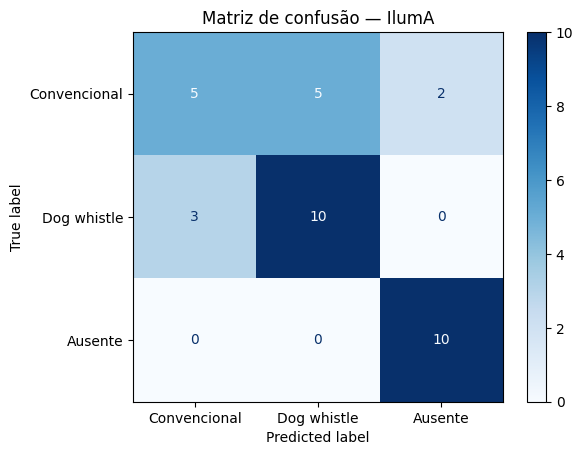

In [131]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

y_true = df_iluma["real"]
y_pred = df_iluma["predito"]

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))

print("\nRelatório de classificação:")
print(classification_report(
    y_true,
    y_pred,
    labels=[0, 1, 2],
    target_names=[
        "Uso convencional",
        "Dog whistle",
        "Termo ausente"
    ],
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Convencional",
        "Dog whistle",
        "Ausente"
    ]
)

disp.plot(cmap="Blues", values_format="d")
plt.title("Matriz de confusão — IlumA")
plt.show()